# Experiment 4 — Spherical Output Constraint

**Magnetic Source Identification · MTH 5320 Project 1 · Strider Settgast**
June 2026

---

**Research question:** Does constraining the regression head to output positions on the ionospheric shell (800–3,100 km altitude) reduce the regression-toward-center failure mode identified in Experiment 3?

**Design:** Single controlled run using Experiment 3 Run B's exact hyperparameters. The only change is replacing the final linear output layer of the regression head with a spherical parametrisation that maps to physically valid positions on the source shell.

**Context:** Experiments 1–3 reached a position RMSE plateau of ~0.187 (per-axis, scaled) despite extensive hyperparameter tuning. Analysis of the error distribution revealed a *regression-toward-center* failure mode: when the inverse problem is ambiguous, predictions collapse toward the geocentre (0, 0, 0) in Cartesian output space — the MSE-minimising hedge — rather than staying on the shell. The spherical constraint eliminates this by construction: every prediction is a valid shell point, so the worst possible hedge is the mean position on the shell (a few thousand km), not the geocentre (~9,000 km from any shell point).

**Controlled variable:** output parametrisation only. All other hyperparameters are identical to Exp 3 Run B, so any RMSE change is attributable solely to the spherical constraint.

> **How to run (Google Colab):** this notebook is **self-contained**. Open it in Colab, set **Runtime → Change runtime type → T4 GPU**, run the first cell (installs deps + loads `L058.txt`), then **Runtime → Run all**.
>
> To compare against Experiment 3, upload `magnetic_model_experiment3.pt` alongside `magnetic_model_experiment4.pt` before running section 4.3.

## 0 · Environment Setup
Installs `optuna` and `tqdm`, then prompts you to upload the sensor file `L058.txt` when the file picker appears.

In [6]:
# ============================================================
# Environment Setup — run this first
# ============================================================
# Colab ships with PyTorch and sklearn pre-installed.
# Optuna and tqdm are the only additions needed.
!pip install optuna tqdm --quiet

# Sensor location file (L058.txt):
#   - If it is already next to this notebook (e.g. a cloned repo), use it.
#   - Otherwise, on Colab, prompt for an upload.
import os
if os.path.exists('L058.txt'):
    print('Found L058.txt in the working directory \u2014 no upload needed.')
else:
    try:
        from google.colab import files
        uploaded = files.upload()  # prompts for L058.txt
    except ImportError:
        raise FileNotFoundError(
            'L058.txt not found. Place it next to this notebook (or upload it on Colab).'
        )


Found L058.txt in the working directory — no upload needed.


## 1 · Simulation & Model Infrastructure
The cells in this section are **shared infrastructure — identical across all three experiment notebooks**. They define the magnetic-field simulator, load the sensor array, build the multi-task network, and set up the Optuna search. Only **Section 2** (dataset parameters) and **Section 3** (the experiment that is run) differ between the three notebooks.

### 1.1 Magnetometer Time Series Simulator (MTSS)

In [7]:
"""
Magnetometer Time Series Simulator for Magnetic Localization Research

This module provides a high-fidelity simulator for generating synthetic
magnetometer data from dipole sources, designed for training neural networks
for magnetic source localization.

Author: Strider Settgast with Deepseek
Date: 2026-06-01
Version: 1.0.0
"""

import numpy as np
from typing import Optional, Tuple, Dict, List
from dataclasses import dataclass
import warnings
from enum import Enum


class SourceType(Enum):
    """Types of magnetic sources that can be simulated."""
    DIPOLE = "dipole"
    MONOPOLE = "monopole"  # Not physically real but useful for testing
    #QUADRUPOLE = "quadrupole"


class NoiseModel(Enum):
    """Available noise models for sensor simulation."""
    GAUSSIAN = "gaussian"
    UNIFORM = "uniform"
    MIXED = "mixed"  # Combination of Gaussian and outliers


@dataclass
class SimulatorConfig:
    """
    Configuration class for the TimeSeriesSimulator.

    Attributes:
        sensor_positions: (n_sensors, 3) array of sensor coordinates
        n_sensors: Number of sensors (auto-detected from positions)
        magnetic_constant: mu_0/(4pi) in SI units (default 1e-7 for normalized)
        default_source_bounds: [min, max] for source position cube
        default_moment_range: [min, max] for magnetic moment magnitude
        noise_std: Standard deviation for Gaussian noise
        noise_outlier_fraction: Fraction of outliers for robust testing
        random_seed: For reproducibility
        normalize_outputs: Whether to normalize target positions
        output_bounds: Bounds for output normalization (if used)
    """
    sensor_positions: np.ndarray
    magnetic_constant: float = 1e-7  # mu_0/(4pi) in SI, or 1.0 for normalized
    default_source_bounds: Tuple[float, float] = (-5.0, 5.0)
    default_moment_range: Tuple[float, float] = (0.5, 2.0)
    noise_std: float = 0.01
    noise_outlier_fraction: float = 0.01
    random_seed: Optional[int] = 42
    normalize_outputs: bool = False
    output_bounds: Optional[Tuple[float, float]] = None

    def __post_init__(self):
        """Validate configuration after initialization."""
        self.n_sensors = len(self.sensor_positions)
        if self.sensor_positions.shape[1] != 3:
            raise ValueError(f"Sensor positions must have 3 columns, got {self.sensor_positions.shape[1]}")

        if self.random_seed is not None:
            np.random.seed(self.random_seed)

        if self.output_bounds is None:
            self.output_bounds = self.default_source_bounds


class TimeSeriesSimulator:
    """
    Industry-grade simulator for magnetometer time series data.

    This class generates realistic magnetic field readings from moving or static
    dipole sources, with configurable noise, sensor layouts, and source dynamics.

    Features:
        - Static and moving source simulation
        - Multiple noise models (Gaussian, uniform, mixed)
        - Sensor noise and dropout simulation
        - Temporal correlation for realistic time series
        - Batching and streaming data generation
        - Built-in visualization tools

    Examples:
        >>> # Initialize with sensor positions
        >>> sensor_positions = np.random.rand(29, 3) * 10
        >>> sim = TimeSeriesSimulator(sensor_positions)
        >>>
        >>> # Generate static source data
        >>> X, y = sim.generate_batch(n_samples=1000)
        >>>
        >>> # Generate moving source time series
        >>> trajectory = lambda t: np.array([np.sin(t), np.cos(t), t*0.1])
        >>> X_series, y_series = sim.generate_time_series(
        ...     n_timesteps=500,
        ...     trajectory_func=trajectory
        ... )
    """

    def __init__(self, sensor_positions: np.ndarray, config: Optional[SimulatorConfig] = None):
        """
        Initialize the simulator with sensor geometry.

        Args:
            sensor_positions: (n_sensors, 3) array of sensor coordinates in meters
            config: Optional SimulatorConfig object. If None, uses defaults.
        """
        self.sensor_positions = sensor_positions
        self.n_sensors = len(sensor_positions)

        if config is None:
            config = SimulatorConfig(sensor_positions=sensor_positions)
        else:
            config.sensor_positions = sensor_positions
            config.__post_init__()

        self.config = config
        self._validate_sensor_positions()

        # Pre-compute sensor positions for efficiency
        self.sensor_positions = config.sensor_positions
        self.n_sensors = config.n_sensors
        self.n_features = self.n_sensors * 3  # Bx, By, Bz for each sensor

        # Statistics for online normalization (if needed)
        self.input_mean = None
        self.input_std = None
        self.output_mean = None
        self.output_std = None

        print(f"✅ Simulator initialized: {self.n_sensors} sensors, {self.n_features} features")

    def _validate_sensor_positions(self):
        """Validate that sensor positions are physically reasonable."""
        if np.any(np.isnan(self.sensor_positions)):
            raise ValueError("Sensor positions contain NaN values")
        if np.any(np.isinf(self.sensor_positions)):
            raise ValueError("Sensor positions contain infinite values")

        # Check for duplicate sensors (within 1mm tolerance)
        unique_positions = np.unique(np.round(self.sensor_positions, decimals=6), axis=0)
        if len(unique_positions) < self.n_sensors:
            warnings.warn(f"Duplicate sensor positions detected. {self.n_sensors - len(unique_positions)} duplicates found.")

    def monopole_field(self,
                       sensor_pos: np.ndarray,
                       source_pos: np.ndarray,
                       magnetic_charge: float) -> np.ndarray:
        """
        Calculate magnetic field from a theoretical monopole (1/r^2 falloff).
        """
        r_vec = sensor_pos - source_pos
        r = np.linalg.norm(r_vec)
        if r < 1e-9:
            return np.zeros(3)

        r_hat = r_vec / r
        B = (r_hat) / (r**2)
        B *= self.config.magnetic_constant * magnetic_charge

        return B

    def dipole_field(self,
                     sensor_pos: np.ndarray,
                     source_pos: np.ndarray,
                     magnetic_moment: np.ndarray) -> np.ndarray:
        """
        Calculate magnetic field from a dipole source at a single sensor.

        Args:
            sensor_pos: (3,) array of sensor position [x, y, z]
            source_pos: (3,) array of source position [x, y, z]
            magnetic_moment: (3,) array of magnetic moment vector [mx, my, mz]

        Returns:
            (3,) array of magnetic field [Bx, By, Bz] in Tesla (or normalized units)

        Raises:
            ValueError: If inputs have incorrect shapes
        """
        # Input validation
        if sensor_pos.shape != (3,):
            raise ValueError(f"sensor_pos must be (3,), got {sensor_pos.shape}")
        if source_pos.shape != (3,):
            raise ValueError(f"source_pos must be (3,), got {source_pos.shape}")
        if magnetic_moment.shape != (3,):
            raise ValueError(f"magnetic_moment must be (3,), got {magnetic_moment.shape}")

        # Calculate relative position vector
        r_vec = sensor_pos - source_pos
        r = np.linalg.norm(r_vec)

        # Avoid division by zero (sensor at source location)
        if r < 1e-9:
            return np.zeros(3)

        r_hat = r_vec / r
        m_dot_r_hat = np.dot(magnetic_moment, r_hat)

        # Dipole field equation
        B = (3 * r_hat * m_dot_r_hat - magnetic_moment) / (r**3)

        # Apply magnetic constant (normalization)
        B *= self.config.magnetic_constant

        return B


    def generate_source(self) -> Tuple[np.ndarray, np.ndarray]:
        """
        Generate a random magnetic source (position and moment).

        Returns:
            Tuple of (source_position, magnetic_moment)

        Note:
            Position is uniform within source_bounds.
            Moment magnitude is uniform within moment_range.
            Moment direction is uniformly distributed on sphere.
        """
        # Random source position within bounds
        low, high = self.config.default_source_bounds
        source_pos = np.random.uniform(low, high, size=3)

        # Random magnetic moment magnitude
        mag_low, mag_high = self.config.default_moment_range
        moment_magnitude = np.random.uniform(mag_low, mag_high)

        # Random direction on sphere (uniform distribution)
        direction = np.random.randn(3)
        direction /= np.linalg.norm(direction)

        magnetic_moment = direction * moment_magnitude

        return source_pos, magnetic_moment

    def compute_fields(self, source_pos: np.ndarray, magnetic_moment: np.ndarray, source_type: SourceType = SourceType.DIPOLE) -> np.ndarray:
        """
        Compute magnetic fields at all sensors for a given source.

        Args:
            source_pos: (3,) array of source position
            magnetic_moment: (3,) array of magnetic moment
            source_type: The type of magnetic source (Enum)

        Returns:
            (n_features,) array of flattened sensor readings (Bx,By,Bz for each sensor)
        """
        fields = []
        for sensor_pos in self.sensor_positions:
            if source_type == SourceType.DIPOLE:
                B = self.dipole_field(sensor_pos, source_pos, magnetic_moment)
            elif source_type == SourceType.MONOPOLE:
                charge = np.linalg.norm(magnetic_moment)
                B = self.monopole_field(sensor_pos, source_pos, charge)

            fields.extend(B)

        return np.array(fields)

    def add_noise(self,
                  fields: np.ndarray,
                  noise_model: NoiseModel = NoiseModel.GAUSSIAN) -> np.ndarray:
        """
        Add realistic noise to sensor readings.

        Args:
            fields: Clean magnetic field readings
            noise_model: Type of noise to add

        Returns:
            Noisy field readings
        """
        noisy = fields.copy()

        if noise_model == NoiseModel.GAUSSIAN:
            noise = np.random.normal(0, self.config.noise_std, size=fields.shape)
            noisy += noise

        elif noise_model == NoiseModel.UNIFORM:
            noise_range = self.config.noise_std * np.sqrt(3)  # Match variance
            noise = np.random.uniform(-noise_range, noise_range, size=fields.shape)
            noisy += noise

        elif noise_model == NoiseModel.MIXED:
            # Gaussian noise
            noise = np.random.normal(0, self.config.noise_std, size=fields.shape)
            noisy += noise

            # Add outliers
            n_outliers = int(len(fields) * self.config.noise_outlier_fraction)
            outlier_indices = np.random.choice(len(fields), n_outliers, replace=False)
            outlier_magnitude = self.config.noise_std * 10
            noisy[outlier_indices] += np.random.normal(0, outlier_magnitude, size=n_outliers)

        return noisy

    def generate_sample(self,
                        source_pos: Optional[np.ndarray] = None,
                        magnetic_moment: Optional[np.ndarray] = None,
                        add_noise: bool = True,
                        noise_model: NoiseModel = NoiseModel.GAUSSIAN) -> Tuple[np.ndarray, np.ndarray]:
        """
        Generate a single training sample.

        Args:
            source_pos: Optional source position (random if None)
            magnetic_moment: Optional magnetic moment (random if None)
            add_noise: Whether to add noise to the readings
            noise_model: Which noise model to use

        Returns:
            Tuple of (features, target) where:
                features: (n_features,) array of magnetic field readings
                target: (3,) array of source position
        """
        random_pos, random_moment = self.generate_source()

        if source_pos is None:
            source_pos = random_pos
        if magnetic_moment is None:
            magnetic_moment = random_moment

        fields = self.compute_fields(source_pos, magnetic_moment)

        if add_noise:
            fields = self.add_noise(fields, noise_model)

        target = source_pos.copy()

        # Optional output normalization
        if self.config.normalize_outputs:
            low, high = self.config.output_bounds
            target = (target - low) / (high - low) * 2 - 1  # Normalize to [-1, 1]

        return fields, target

    def generate_batch(self,
                       n_samples: int,
                       add_noise: bool = True,
                       noise_model: NoiseModel = NoiseModel.GAUSSIAN) -> Tuple[np.ndarray, np.ndarray]:
        """
        Generate a batch of training samples.

        Args:
            n_samples: Number of samples to generate
            add_noise: Whether to add noise
            noise_model: Noise model to use

        Returns:
            Tuple of (X, y) where:
                X: (n_samples, n_features) array of features
                y: (n_samples, 3) array of targets
        """
        X = np.zeros((n_samples, self.n_features))
        y = np.zeros((n_samples, 3))

        for i in range(n_samples):
            X[i], y[i] = self.generate_sample(add_noise=add_noise, noise_model=noise_model)

        return X, y

    def generate_time_series(self,
                            n_timesteps: int,
                            trajectory_func: Optional[callable] = None,
                            moment_func: Optional[callable] = None,
                            dt: float = 0.01,
                            add_noise: bool = True,
                            noise_model: NoiseModel = NoiseModel.GAUSSIAN) -> Tuple[np.ndarray, np.ndarray]:
        """
        Generate a time series with moving source.

        Args:
            n_timesteps: Number of time steps to generate
            trajectory_func: Function t -> (x, y, z) position.
                            If None, uses random walk.
            moment_func: Function t -> (mx, my, mz) magnetic moment.
                        If None, uses constant random moment.
            dt: Time step duration in seconds
            add_noise: Whether to add noise
            noise_model: Noise model to use

        Returns:
            Tuple of (X, y) where:
                X: (n_timesteps, n_features) time series of features
                y: (n_timesteps, 3) time series of source positions

        Examples:
            >>> # Linear motion
            >>> def linear_motion(t):
            ...     return np.array([t, 0, 0])
            >>> X, y = sim.generate_time_series(1000, trajectory_func=linear_motion)

            >>> # Circular motion with sinusoidal moment
            >>> def circular_motion(t):
            ...     return np.array([np.sin(t), np.cos(t), 0])
            >>> X, y = sim.generate_time_series(1000, trajectory_func=circular_motion)
        """
        times = np.arange(n_timesteps) * dt

        if trajectory_func is None:
            # Random walk trajectory
            positions = np.zeros((n_timesteps, 3))
            positions[0] = np.random.uniform(*self.config.default_source_bounds, size=3)
            step_size = 0.1
            for t in range(1, n_timesteps):
                positions[t] = positions[t-1] + np.random.randn(3) * step_size
                # Keep within bounds (soft boundary with reflection)
                low, high = self.config.default_source_bounds
                for dim in range(3):
                    if positions[t, dim] < low:
                        positions[t, dim] = low + (low - positions[t, dim])
                    elif positions[t, dim] > high:
                        positions[t, dim] = high - (positions[t, dim] - high)
        else:
            positions = np.array([trajectory_func(t) for t in times])

        if moment_func is None:
            # Constant random moment
            _, magnetic_moment = self.generate_source()
            moments = np.tile(magnetic_moment, (n_timesteps, 1))
        else:
            moments = np.array([moment_func(t) for t in times])

        # Generate fields for each time step
        X = np.zeros((n_timesteps, self.n_features))
        y = positions.copy()

        for i in range(n_timesteps):
            fields = self.compute_fields(positions[i], moments[i])
            if add_noise:
                fields = self.add_noise(fields, noise_model)
            X[i] = fields

        return X, y

    def compute_snr(self, clean_fields: np.ndarray, noisy_fields: np.ndarray) -> float:
        """
        Compute Signal-to-Noise Ratio for generated data.

        Args:
            clean_fields: Clean magnetic field readings
            noisy_fields: Noisy readings

        Returns:
            SNR in decibels (dB)
        """
        signal_power = np.mean(clean_fields ** 2)
        noise_power = np.mean((clean_fields - noisy_fields) ** 2)

        if noise_power < 1e-12:
            return float('inf')

        snr = 10 * np.log10(signal_power / noise_power)
        return snr

    def get_data_statistics(self, X: np.ndarray, y: np.ndarray) -> Dict[str, Dict[str, float]]:
        """
        Compute comprehensive statistics for generated data.

        Args:
            X: Features array (n_samples, n_features)
            y: Targets array (n_samples, 3)

        Returns:
            Dictionary with statistics for inputs and outputs
        """
        stats = {
            'input': {
                'mean': np.mean(X, axis=0).tolist(),
                'std': np.std(X, axis=0).tolist(),
                'min': np.min(X, axis=0).tolist(),
                'max': np.max(X, axis=0).tolist(),
                'has_nan': np.any(np.isnan(X)),
                'has_inf': np.any(np.isinf(X))
            },
            'output': {
                'mean': np.mean(y, axis=0).tolist(),
                'std': np.std(y, axis=0).tolist(),
                'min': np.min(y, axis=0).tolist(),
                'max': np.max(y, axis=0).tolist(),
                'has_nan': np.any(np.isnan(y)),
                'has_inf': np.any(np.isinf(y))
            }
        }
        return stats

    def visualize_sensor_array(self, ax=None):
        """
        Visualize the 3D positions of sensors.

        Args:
            ax: Matplotlib 3D axis (creates new if None)
        """
        try:
            import matplotlib.pyplot as plt
            from mpl_toolkits.mplot3d import Axes3D

            if ax is None:
                fig = plt.figure(figsize=(10, 8))
                ax = fig.add_subplot(111, projection='3d')

            ax.scatter(self.sensor_positions[:, 0],
                      self.sensor_positions[:, 1],
                      self.sensor_positions[:, 2],
                      c='red', marker='o', s=50, label='Sensors')

            ax.set_xlabel('X (m)')
            ax.set_ylabel('Y (m)')
            ax.set_zlabel('Z (m)')
            ax.set_title(f'Sensor Array Layout ({self.n_sensors} Sensors)')
            ax.legend()

            # Set equal aspect ratio
            max_range = np.max([
                np.ptp(self.sensor_positions[:, 0]),
                np.ptp(self.sensor_positions[:, 1]),
                np.ptp(self.sensor_positions[:, 2])
            ]) / 2.0
            mid_x = np.mean(self.sensor_positions[:, 0])
            mid_y = np.mean(self.sensor_positions[:, 1])
            mid_z = np.mean(self.sensor_positions[:, 2])
            ax.set_xlim(mid_x - max_range, mid_x + max_range)
            ax.set_ylim(mid_y - max_range, mid_y + max_range)
            ax.set_zlim(mid_z - max_range, mid_z + max_range)

            return ax

        except ImportError:
            print("Matplotlib not available. Install with: pip install matplotlib")
            return None

    def save_dataset(self, X: np.ndarray, y: np.ndarray, filepath: str):
        """
        Save generated dataset to disk (NPZ format).

        Args:
            X: Features array
            y: Targets array
            filepath: Path to save file (.npz extension recommended)
        """
        np.savez_compressed(filepath, X=X, y=y,
                           sensor_positions=self.sensor_positions,
                           config=vars(self.config))
        print(f"✅ Dataset saved to {filepath}")

    @classmethod
    def load_dataset(cls, filepath: str):
        """
        Load a saved dataset.

        Args:
            filepath: Path to saved .npz file

        Returns:
            Dictionary containing X, y, sensor_positions, and config
        """
        data = np.load(filepath, allow_pickle=True)
        return {
            'X': data['X'],
            'y': data['y'],
            'sensor_positions': data['sensor_positions'],
            'config': data['config'].item() if 'config' in data else None
        }

### 1.2 Sensor Array Loader (`L058.txt` → 29 stations)

In [8]:
import numpy as np
import pandas as pd


## Load the sensor locations

# Define column names
column_names = ['Station', 'Lshell', 'M_Lat', 'M_Lon', 'G_lat', 'G_lon']

# Read the file using read_fwf (fixed-width format)
locations_df = pd.read_fwf('L058.txt', names=column_names, skiprows=1)  # skiprows=1 to skip the "029" line

# Sort by station name
locations_df.sort_values(by='Station', inplace=True)

# --- 3D Cartesian Conversion ---
# Mean radius of Earth in kilometers (use 1.0 for a normalized unit sphere)
R = 6371.0

# Convert geographic latitude and longitude to radians
lat_rad = np.radians(locations_df["G_lat"])
lon_rad = np.radians(locations_df["G_lon"])

# Compute X, Y, and Z coordinates
locations_df["X"] = R * np.cos(lat_rad) * np.cos(lon_rad)
locations_df["Y"] = R * np.cos(lat_rad) * np.sin(lon_rad)
locations_df["Z"] = R * np.sin(lat_rad)

# Extract X, Y, Z columns into a 2D NumPy array
sensors_xyz_locations = locations_df[["X", "Y", "Z"]].to_numpy()

# Check the shape of your new array
print(f"\n \n✓ Loaded: - Sensor Locations {sensors_xyz_locations.shape[0]} rows × {sensors_xyz_locations.shape[1]} columns")
print(f"\nFirst 5 rows (preview):")
print(sensors_xyz_locations[:5, :5])


 
✓ Loaded: - Sensor Locations 29 rows × 3 columns

First 5 rows (preview):
[[-3933.43787518  3461.69610765 -3624.13679935]
 [-1456.21299991 -3381.28875582  5199.6125864 ]
 [-2151.33376015  4375.94273603  4100.30843027]
 [-4352.20723163  3755.39914318 -2746.80004522]
 [-4456.93788538  2677.99845678 -3681.53092495]]


### 1.3 Multi-Task Neural Network — Spherical Regression Head

The shared backbone, classification head, and all supporting classes (`ResidualBlock`, `MagneticSourceLoss`, `EarlyStopping`, `ModelTrainer`) are **identical to Experiments 1–3**.

**Key modification for Experiment 4:** the regression head's final layer is replaced by a `SphericalOutputLayer` that parametrises the prediction as:

- **Colatitude** θ ∈ [0, π]  via sigmoid
- **Longitude** φ ∈ [−π, π]  via tanh
- **Geocentric radius** r ∈ [7,171, 9,471] km  via sigmoid scaled to the shell altitude range

The layer converts (θ, φ, r) → Cartesian km → MinMaxScaler [0, 1] space so the loss function and all downstream evaluation code are unchanged.

`MultiTaskMagneticNet` accepts two new optional constructor arguments (`use_spherical_loc`, `loc_scaler_min`, `loc_scaler_range`). When `use_spherical_loc=False` (the default) the network is identical to Experiments 1–3.

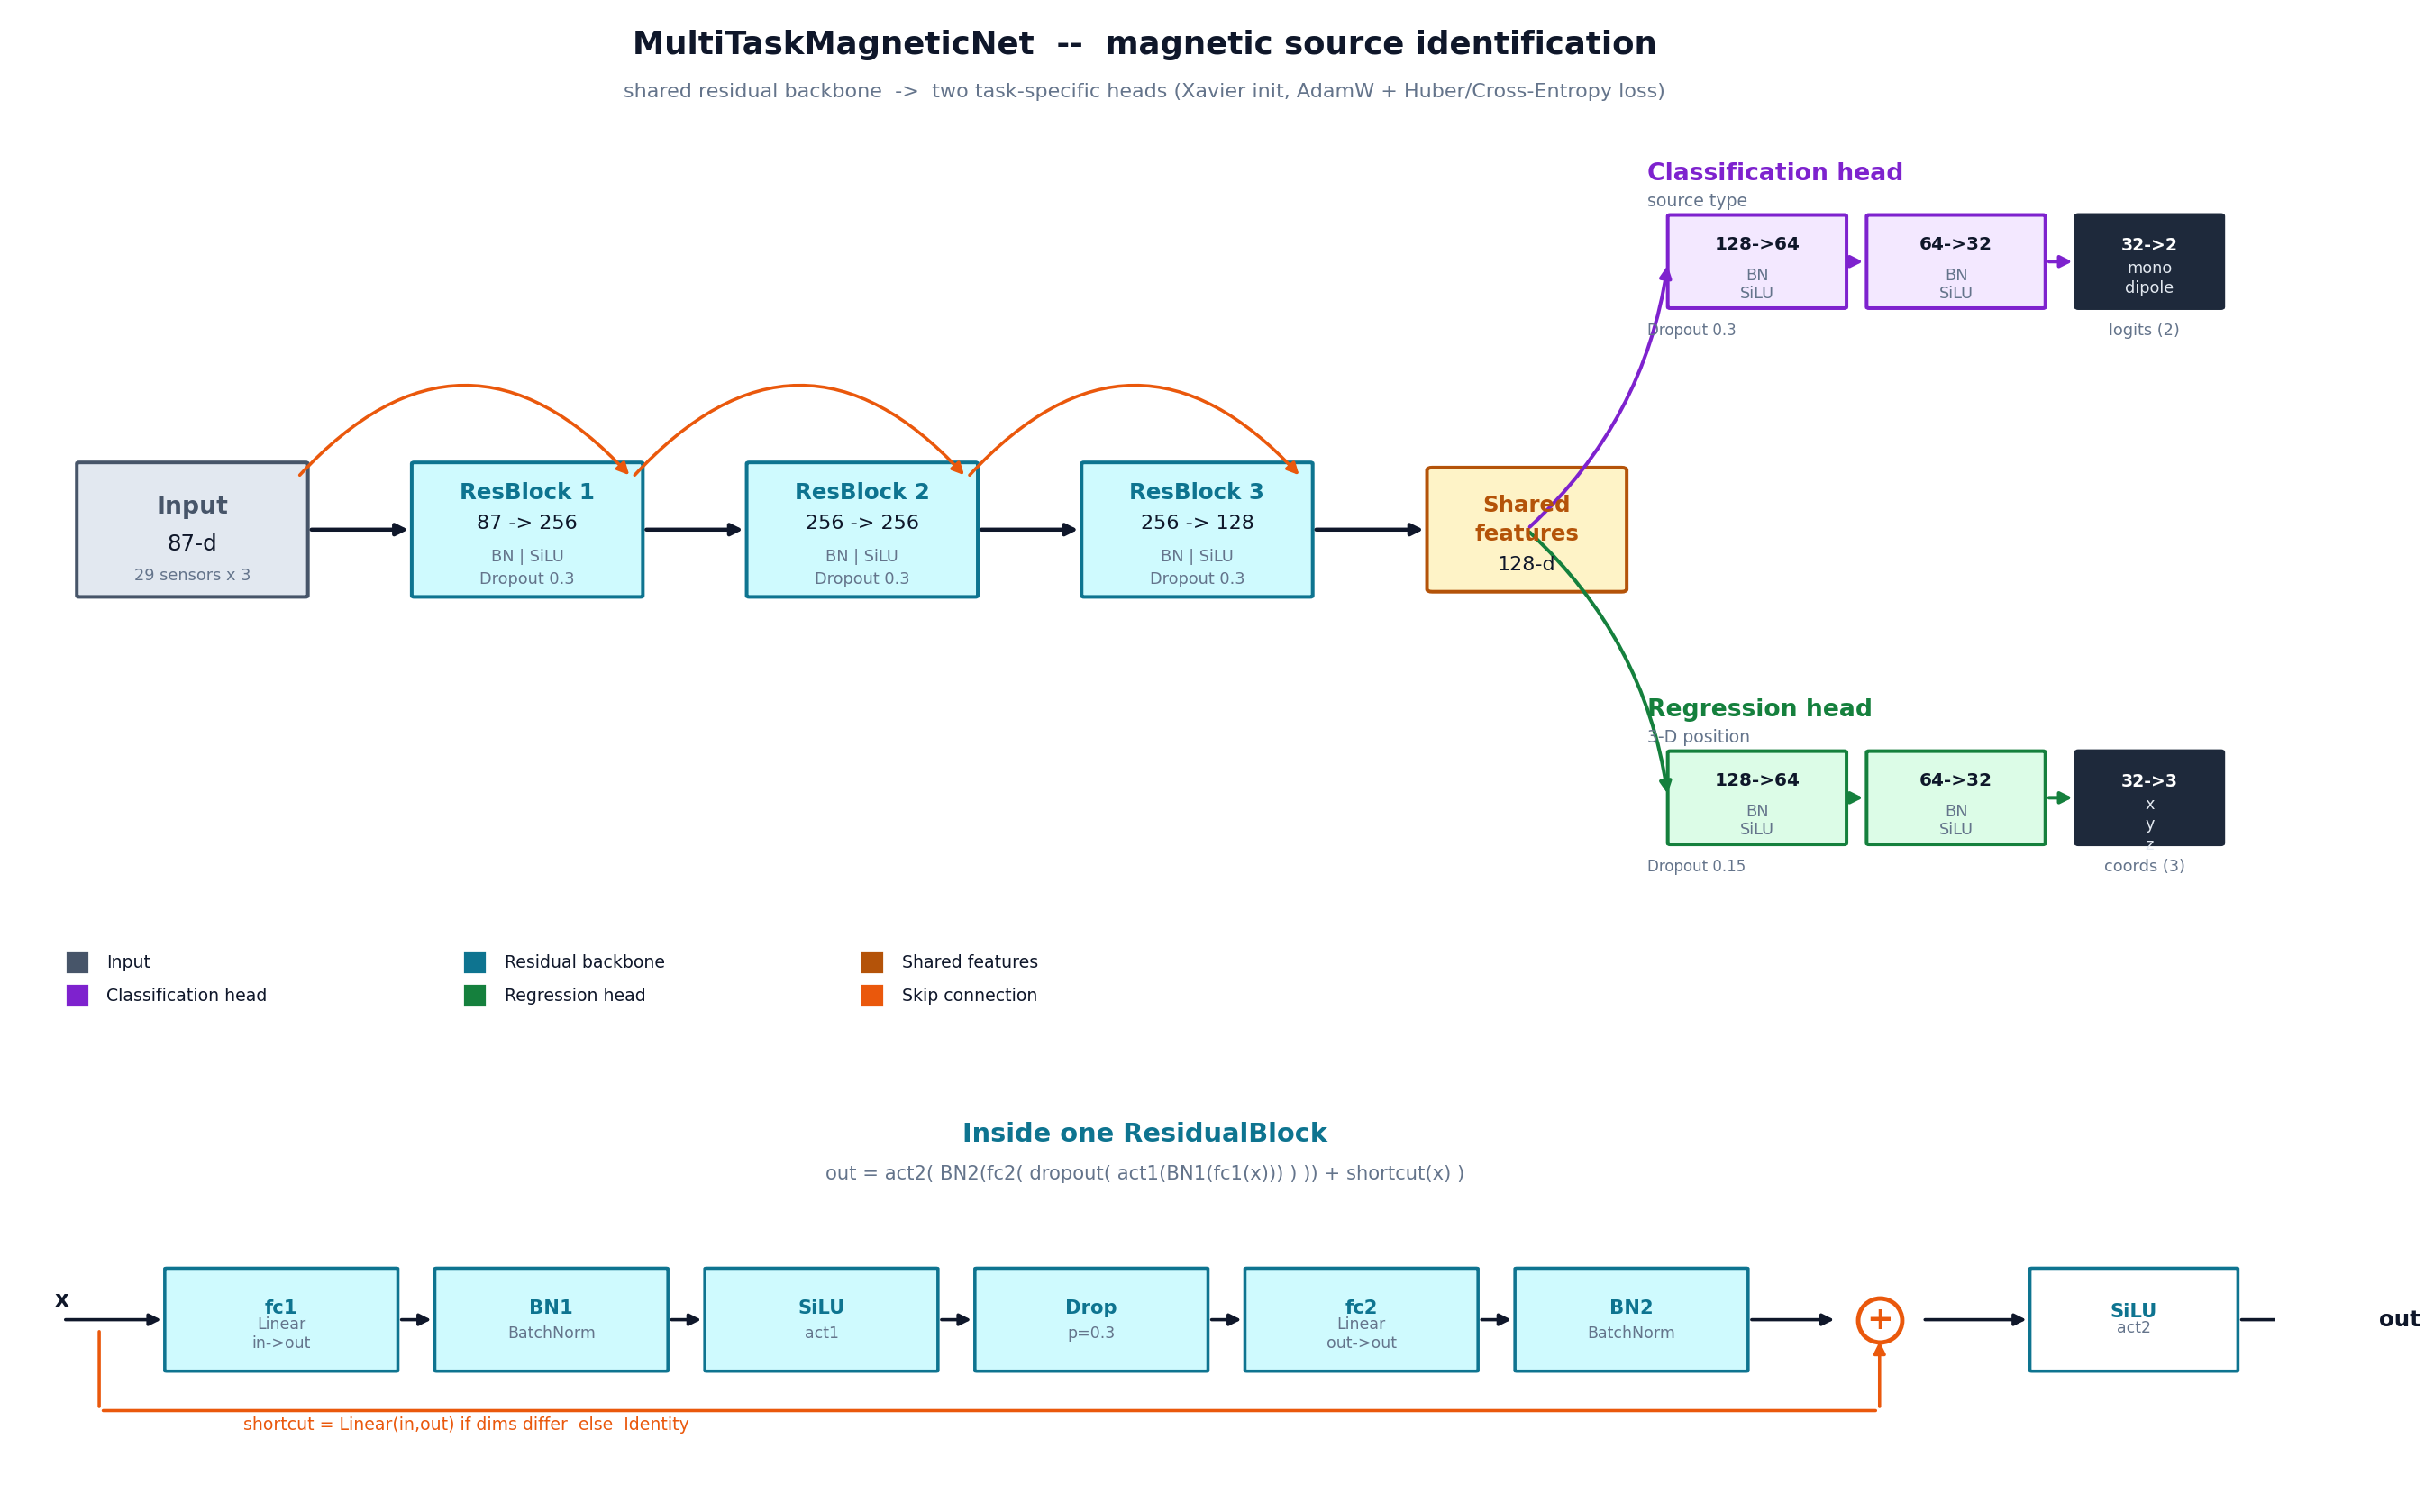

In [9]:
"""
Multi-Task Neural Network for Magnetic Source Identification
Industry-standard architecture with residual connections, batch normalization,
and proper regularization for geophysical inversion problems.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from typing import Dict, Tuple, Optional, List
from dataclasses import dataclass
import optuna
from optuna.trial import Trial
import warnings
from torch.utils.data import DataLoader


@dataclass
class ModelConfig:
    """Configuration for the multi-task magnetic source identification model."""
    # Architecture
    input_dim: int = 87  # 29 sensors × 3 components
    hidden_dims: List[int] = None  # Will be set in __post_init__
    dropout_rate: float = 0.3
    activation: str = "silu"  # SiLU/Swish often better for geophysical data

    # Task-specific heads
    loc_hidden_dims: List[int] = None  # Regression head
    type_hidden_dims: List[int] = None  # Classification head

    # Regularization
    weight_decay: float = 1e-5
    batch_norm_momentum: float = 0.1
    use_residual: bool = True

    # Training
    learning_rate: float = 1e-3
    batch_size: int = 64           # Mini-batch size (tunable by Optuna)
    loc_loss_weight: float = 1.0  # Weight for position loss
    type_loss_weight: float = 1.0  # Weight for type classification loss

    def __post_init__(self):
        if self.hidden_dims is None:
            self.hidden_dims = [256, 256, 128]
        if self.loc_hidden_dims is None:
            self.loc_hidden_dims = [64, 32]
        if self.type_hidden_dims is None:
            self.type_hidden_dims = [64, 32]


class ResidualBlock(nn.Module):
    """Residual block with batch normalization and dropout.

    Uses a projection shortcut so the block works even when its input and
    output dimensions differ (standard ResNet practice). Each block also owns
    its own activation instances rather than sharing a single module passed in
    from the parent network.
    """

    @staticmethod
    def _make_activation(activation_type: str) -> nn.Module:
        if activation_type == "relu":
            return nn.ReLU()
        elif activation_type == "silu":
            return nn.SiLU()
        elif activation_type == "gelu":
            return nn.GELU()
        else:
            raise ValueError(f"Unsupported activation: {activation_type}")

    def __init__(self, in_dim: int, out_dim: int, dropout_rate: float,
                 activation_type: str, bn_momentum: float = 0.1):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, out_dim)
        self.bn1 = nn.BatchNorm1d(out_dim, momentum=bn_momentum)
        self.fc2 = nn.Linear(out_dim, out_dim)
        self.bn2 = nn.BatchNorm1d(out_dim, momentum=bn_momentum)
        self.dropout = nn.Dropout(dropout_rate)

        # Project the residual when dimensions change so (x + residual) aligns.
        if in_dim != out_dim:
            self.shortcut = nn.Linear(in_dim, out_dim, bias=False)
        else:
            self.shortcut = nn.Identity()

        # Fresh activation instances owned by this block (no shared reference).
        self.activation1 = self._make_activation(activation_type)
        self.activation2 = self._make_activation(activation_type)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = self.shortcut(x)
        x = self.activation1(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.bn2(self.fc2(x))
        x = self.activation2(x + residual)
        return x



# ─── Shell geometry constants ──────────────────────────────────────────────────
EARTH_RADIUS_KM = 6371.0
SHELL_MIN_KM    = EARTH_RADIUS_KM + 800    # 7,171 km  (min source altitude)
SHELL_RANGE_KM  = 3100.0 - 800.0           # 2,300 km  (altitude band width)


class SphericalOutputLayer(nn.Module):
    """
    Replaces the final nn.Linear(→3) of the regression head.

    Maps backbone features → a unit-sphere direction vector + shell radius →
    Cartesian km → MinMaxScaler [0,1] space (identical format to the
    original Cartesian head so the loss function needs no changes).

    Uses a direction-vector + radius parameterisation:
        direction = F.normalize(raw[:, :3])  — unit vector, no angular singularity
        r         = SHELL_MIN + sigmoid(raw[:, 3]) * SHELL_RANGE  — shell-constrained

    This is fully symmetric in X/Y/Z (no preferred axis) and avoids the
    sin(phi)=0 collapse of the original tanh·π longitude encoding, which
    produces Y=0 at both tanh's initialisation point (x=0) and its
    saturation limits (x→±∞).
    """

    def __init__(self, in_dim: int,
                 scaler_min: "array-like",
                 scaler_range: "array-like"):
        super().__init__()
        self.linear = nn.Linear(in_dim, 4)   # (dir_x, dir_y, dir_z, r_raw)
        self.register_buffer(
            'scaler_min',   torch.as_tensor(scaler_min,   dtype=torch.float32))
        self.register_buffer(
            'scaler_range', torch.as_tensor(scaler_range, dtype=torch.float32))

    def reset_parameters(self):
        """Re-initialise with gain=1.0 so ||dir_raw|| starts at a moderate scale.

        Called from MultiTaskMagneticNet after the global xavier(gain=0.5) sweep,
        which would leave direction raw-outputs so small that F.normalize
        amplifies gradients unnecessarily.
        """
        nn.init.xavier_normal_(self.linear.weight, gain=1.0)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        raw       = self.linear(x)                                        # (B, 4)
        direction = F.normalize(raw[:, :3], dim=1, eps=1e-8)             # unit sphere (B, 3)
        r         = SHELL_MIN_KM + torch.sigmoid(raw[:, 3]) * SHELL_RANGE_KM  # (B,) km
        xyz_km    = r.unsqueeze(1) * direction                            # (B, 3) km

        # Replicate MinMaxScaler: x_scaled = (x − min) / range
        return (xyz_km - self.scaler_min) / self.scaler_range             # (B, 3) in [0,1]

class MultiTaskMagneticNet(nn.Module):
    """
    Multi-task neural network for magnetic source localization and classification.

    Architecture:
    - Shared backbone: Processes magnetic field readings
    - Regression head: Predicts 3D source position (x, y, z)
    - Classification head: Predicts source type (monopole/dipole)

    Features:
    - Residual connections for better gradient flow
    - Batch normalization for stable training
    - Task-specific heads with proper output activations
    """

    def __init__(self, config: ModelConfig,
                 use_spherical_loc: bool = False,
                 loc_scaler_min=None, loc_scaler_range=None):
        super().__init__()
        self.config = config
        self.use_spherical_loc = use_spherical_loc

        # Activation function
        if config.activation == "relu":
            self.activation = nn.ReLU()
        elif config.activation == "silu":
            self.activation = nn.SiLU()
        elif config.activation == "gelu":
            self.activation = nn.GELU()
        else:
            raise ValueError(f"Unsupported activation: {config.activation}")

        # ========== Shared Backbone ==========
        layers = []
        prev_dim = config.input_dim

        for i, hidden_dim in enumerate(config.hidden_dims):
            if config.use_residual:
                # Projection shortcut handles any dimension change, so the
                # residual block can be applied to every layer unconditionally.
                layers.append(
                    ResidualBlock(prev_dim, hidden_dim, config.dropout_rate,
                                  config.activation, config.batch_norm_momentum)
                )
            else:
                layers.append(nn.Linear(prev_dim, hidden_dim))
                layers.append(nn.BatchNorm1d(hidden_dim, momentum=config.batch_norm_momentum))
                layers.append(self.activation)
                layers.append(nn.Dropout(config.dropout_rate))

            prev_dim = hidden_dim

        self.shared_backbone = nn.Sequential(*layers)
        self.shared_dim = prev_dim

        # ========== Regression Head (Position) ==========
        loc_layers = []
        prev_dim = self.shared_dim

        for hidden_dim in config.loc_hidden_dims:
            loc_layers.append(nn.Linear(prev_dim, hidden_dim))
            loc_layers.append(nn.BatchNorm1d(hidden_dim, momentum=config.batch_norm_momentum))
            loc_layers.append(self._make_activation())  # fresh instance per layer
            loc_layers.append(nn.Dropout(config.dropout_rate * 0.5))  # less dropout for regression
            prev_dim = hidden_dim

        # Output layer: either constrained spherical or raw Cartesian
        if use_spherical_loc:
            # SphericalOutputLayer contains its own Linear(→3) +
            # physical parametrisation + MinMaxScaler conversion.
            loc_layers.append(
                SphericalOutputLayer(prev_dim, loc_scaler_min, loc_scaler_range)
            )
        else:
            loc_layers.append(nn.Linear(prev_dim, 3))
        self.regression_head = nn.Sequential(*loc_layers)

        # ========== Classification Head (Source Type) ==========
        type_layers = []
        prev_dim = self.shared_dim

        for hidden_dim in config.type_hidden_dims:
            type_layers.append(nn.Linear(prev_dim, hidden_dim))
            type_layers.append(nn.BatchNorm1d(hidden_dim, momentum=config.batch_norm_momentum))
            type_layers.append(self._make_activation())  # fresh instance per layer
            type_layers.append(nn.Dropout(config.dropout_rate))
            prev_dim = hidden_dim

        # Output layer - logits for 2 classes (monopole, dipole)
        type_layers.append(nn.Linear(prev_dim, 2))
        self.classification_head = nn.Sequential(*type_layers)

        # Initialize weights
        self._initialize_weights()

        # Re-initialise the spherical head after the global xavier(gain=0.5) sweep
        # so F.normalize sees moderate-size raw direction vectors.
        if use_spherical_loc:
            last = self.regression_head[-1]
            if isinstance(last, SphericalOutputLayer):
                last.reset_parameters()

    def _make_activation(self) -> nn.Module:
        """Return a fresh, independent activation instance.

        Each call produces a new object so no two layers in the network
        share the same module reference — avoiding inplace-operation
        conflicts and double-registration in PyTorch's module graph.
        """
        if self.config.activation == "relu":  return nn.ReLU()
        elif self.config.activation == "silu": return nn.SiLU()
        elif self.config.activation == "gelu": return nn.GELU()

    def _initialize_weights(self):
        """Initialize weights using Xavier initialization."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, gain=0.5)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.BatchNorm1d):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass.

        Args:
            x: Input tensor of shape (batch_size, input_dim)

        Returns:
            loc_pred: Position predictions of shape (batch_size, 3)
            type_pred: Type logits of shape (batch_size, 2)
        """
        # Shared features
        features = self.shared_backbone(x)

        # Task-specific predictions
        loc_pred = self.regression_head(features)
        type_pred = self.classification_head(features)

        return loc_pred, type_pred


class MagneticSourceLoss(nn.Module):
    """
    Combined loss for multi-task learning.

    Uses:
    - Huber loss (smooth L1) for position regression (robust to outliers)
    - Cross-entropy loss for source type classification

    Adaptive weighting based on uncertainty (optional).
    """

    def __init__(self, loc_weight: float = 1.0, type_weight: float = 1.0,
                 use_uncertainty_weighting: bool = False, huber_beta: float = 0.1):
        """
        Args:
            loc_weight: Weight for position loss
            type_weight: Weight for classification loss
            use_uncertainty_weighting: Learn task weights automatically (Kendall et al. 2018)
        """
        super().__init__()
        self.loc_weight = loc_weight
        self.type_weight = type_weight
        self.use_uncertainty_weighting = use_uncertainty_weighting

        if use_uncertainty_weighting:
            # Learnable log variances for each task
            self.log_var_loc = nn.Parameter(torch.zeros(1))
            self.log_var_type = nn.Parameter(torch.zeros(1))

        self.loc_loss_fn = nn.SmoothL1Loss(beta=huber_beta)  # Huber loss
        self.type_loss_fn = nn.CrossEntropyLoss()

    def forward(self, loc_pred: torch.Tensor, type_pred: torch.Tensor,
                loc_true: torch.Tensor, type_true: torch.Tensor) -> Dict[str, torch.Tensor]:
        """
        Compute combined loss.

        Args:
            loc_pred: Predicted positions (batch_size, 3)
            type_pred: Predicted type logits (batch_size, 2)
            loc_true: True positions (batch_size, 3)
            type_true: True type indices (batch_size,)

        Returns:
            Dictionary containing individual losses and total loss
        """
        # Position loss (regression)
        loc_loss = self.loc_loss_fn(loc_pred, loc_true)

        # Type loss (classification)
        type_loss = self.type_loss_fn(type_pred, type_true)

        if self.use_uncertainty_weighting:
            # Uncertainty-weighted multi-task loss
            # L = (1/2) * (L1 / exp(s1) + s1 + L2 / exp(s2) + s2)
            loc_weighted = 0.5 * (loc_loss / torch.exp(self.log_var_loc) + self.log_var_loc)
            type_weighted = 0.5 * (type_loss / torch.exp(self.log_var_type) + self.log_var_type)
            total_loss = loc_weighted + type_weighted
        else:
            total_loss = self.loc_weight * loc_loss + self.type_weight * type_loss

        return {
            'total_loss': total_loss,
            'loc_loss': loc_loss,
            'type_loss': type_loss,
            'loc_rmse': torch.sqrt(torch.mean((loc_pred - loc_true) ** 2)),
            'type_acc': (type_pred.argmax(dim=1) == type_true).float().mean()
        }


class EarlyStopping:
    """Early stopping to prevent overfitting."""

    def __init__(self, patience: int = 20, min_delta: float = 1e-5, mode: str = 'min'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_state_dict = None

    def __call__(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False

        if self.mode == 'min':
            improved = score < self.best_score - self.min_delta
        else:
            improved = score > self.best_score + self.min_delta

        if improved:
            self.best_score = score
            self.best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

        return self.early_stop


class ModelTrainer:
    """Industry-standard trainer with metrics tracking and checkpointing."""

    def __init__(self, model: nn.Module, device: torch.device, config: ModelConfig):
        self.model = model.to(device)
        self.device = device
        self.config = config

        # Optimizer with weight decay and momentum
        self.optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config.learning_rate,
            weight_decay=config.weight_decay,
            betas=(0.9, 0.999)
        )

        # Learning rate scheduler with warmup
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=10
        )

        self.criterion = MagneticSourceLoss(
            loc_weight=config.loc_loss_weight,
            type_weight=config.type_loss_weight
        )

        # Metrics tracking
        self.train_history = {'loss': [], 'loc_loss': [], 'type_loss': [], 'loc_rmse': [], 'type_acc': []}
        self.val_history = {'loss': [], 'loc_loss': [], 'type_loss': [], 'loc_rmse': [], 'type_acc': []}

    def train_epoch(self, train_loader: DataLoader) -> Dict[str, float]:
        """Train for one epoch."""
        self.model.train()
        epoch_metrics = {'loss': 0, 'loc_loss': 0, 'type_loss': 0, 'loc_rmse': 0, 'type_acc': 0}

        for X_batch, loc_batch, type_batch in train_loader:
            X_batch = X_batch.to(self.device)
            loc_batch = loc_batch.to(self.device)
            type_batch = type_batch.to(self.device)

            # Forward pass
            loc_pred, type_pred = self.model(X_batch)
            loss_dict = self.criterion(loc_pred, type_pred, loc_batch, type_batch)

            # Backward pass
            self.optimizer.zero_grad()
            loss_dict['total_loss'].backward()

            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

            self.optimizer.step()

            # Accumulate metrics
            for key in epoch_metrics.keys():
                # Loss dict exposes the combined loss as 'total_loss';
                # map our 'loss' accumulator onto it so the keys line up.
                src_key = 'total_loss' if key == 'loss' else key
                epoch_metrics[key] += loss_dict[src_key].item()

        # Average metrics
        n_batches = len(train_loader)
        return {k: v / n_batches for k, v in epoch_metrics.items()}

    @torch.no_grad()
    def evaluate(self, val_loader: DataLoader) -> Dict[str, float]:
        """Evaluate model on validation set."""
        self.model.eval()
        epoch_metrics = {'loss': 0, 'loc_loss': 0, 'type_loss': 0, 'loc_rmse': 0, 'type_acc': 0}

        for X_batch, loc_batch, type_batch in val_loader:
            X_batch = X_batch.to(self.device)
            loc_batch = loc_batch.to(self.device)
            type_batch = type_batch.to(self.device)

            loc_pred, type_pred = self.model(X_batch)
            loss_dict = self.criterion(loc_pred, type_pred, loc_batch, type_batch)

            for key in epoch_metrics.keys():
                # Loss dict exposes the combined loss as 'total_loss';
                # map our 'loss' accumulator onto it so the keys line up.
                src_key = 'total_loss' if key == 'loss' else key
                epoch_metrics[key] += loss_dict[src_key].item()

        n_batches = len(val_loader)
        return {k: v / n_batches for k, v in epoch_metrics.items()}

    def train(self, train_loader: DataLoader, val_loader: DataLoader,
              epochs: int = 200, early_stopping_patience: int = 30) -> Dict:
        """Complete training loop with early stopping."""
        early_stopping = EarlyStopping(patience=early_stopping_patience, mode='min')
        best_val_loss = float('inf')

        for epoch in range(epochs):
            # Train
            train_metrics = self.train_epoch(train_loader)
            for key, value in train_metrics.items():
                self.train_history[key].append(value)

            # Validate
            val_metrics = self.evaluate(val_loader)
            for key, value in val_metrics.items():
                self.val_history[key].append(value)

            # Learning rate scheduling
            self.scheduler.step(val_metrics['loss'])

            # Print progress
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs} | "
                      f"Train Loss: {train_metrics['loss']:.4f} | "
                      f"Val Loss: {val_metrics['loss']:.4f} | "
                      f"Val Loc RMSE: {val_metrics['loc_rmse']:.4f} | "
                      f"Val Type Acc: {val_metrics['type_acc']:.4f}")

            # Early stopping
            if early_stopping(val_metrics['loss'], self.model):
                print(f"Early stopping triggered at epoch {epoch+1}")
                self.model.load_state_dict(early_stopping.best_state_dict)
                break

        return {
            'train_history': self.train_history,
            'val_history': self.val_history,
            'best_val_loss': early_stopping.best_score if early_stopping.best_score else best_val_loss
        }

### 1.4 Training Helpers

`TunableTrainer` is a `ModelTrainer` subclass that applies a tunable `grad_clip` value, a tunable `huber_beta` for the Huber loss, and a tunable `scheduler_factor`. First introduced in Experiment 3 to fix the hardcoded `max_norm=1.0` bug in the base trainer.

In [10]:
class TunableTrainer(ModelTrainer):
    """
    ModelTrainer subclass with tunable grad_clip, loss, and scheduler.

    Overrides train_epoch() to use self.grad_clip instead of the
    hardcoded max_norm=1.0 in the base class. All other behaviour
    (early stopping, metrics tracking, evaluate()) is inherited.
    """

    def __init__(self, model: nn.Module, device: torch.device,
                 config: ModelConfig, grad_clip: float,
                 huber_beta: float, scheduler_factor: float):
        super().__init__(model, device, config)

        # Store tunable values
        self.grad_clip = grad_clip

        # Override criterion with tuned huber_beta
        self.criterion = MagneticSourceLoss(
            loc_weight  = config.loc_loss_weight,
            type_weight = config.type_loss_weight,
            huber_beta  = huber_beta,
        )

        # Override scheduler — also removes verbose=True (crashed PyTorch 2.4)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min',
            factor   = scheduler_factor,
            patience = 10,
        )

    def train_epoch(self, train_loader: DataLoader) -> Dict[str, float]:
        """Train one epoch using self.grad_clip instead of hardcoded 1.0."""
        self.model.train()
        epoch_metrics = {
            'loss': 0, 'loc_loss': 0, 'type_loss': 0,
            'loc_rmse': 0, 'type_acc': 0
        }

        for X_batch, loc_batch, type_batch in train_loader:
            X_batch    = X_batch.to(self.device)
            loc_batch  = loc_batch.to(self.device)
            type_batch = type_batch.to(self.device)

            loc_pred, type_pred = self.model(X_batch)
            loss_dict = self.criterion(loc_pred, type_pred, loc_batch, type_batch)

            self.optimizer.zero_grad()
            loss_dict['total_loss'].backward()

            # Use the tuned clip value — this is the fix vs. Experiments 1 & 2
            torch.nn.utils.clip_grad_norm_(
                self.model.parameters(), max_norm=self.grad_clip
            )

            self.optimizer.step()

            for key in epoch_metrics.keys():
                src_key = 'total_loss' if key == 'loss' else key
                epoch_metrics[key] += loss_dict[src_key].item()

        n_batches = len(train_loader)
        return {k: v / n_batches for k, v in epoch_metrics.items()}

## 2 · Dataset Generation
**Experiment 3 dataset:** 3,200 unique source positions × 2 types × **10 noise realizations** = **64,000 samples**.

**What changed from Experiments 1 & 2:** unique positions were increased (400 → 3,200) while noise realizations were halved (20 → 10). Noise realizations are *correlated* augmentation — they share the same clean field and build noise robustness but add no new spatial information; unique positions add *independent* spatial coverage. Trading the former for the latter (8× more positions for 4× more total samples) is what finally moved the position RMSE off its plateau.

### 2.1 Generate the magnetic-field dataset

In [11]:
import numpy as np
from tqdm import tqdm # Optional: pip install tqdm for a progress bar
import warnings

# --- 1. Configuration & Initialization ---
# Using the 29 Earth-scale sensor locations loaded
EARTH_RADIUS = 6371.0

config = SimulatorConfig(
    sensor_positions=sensors_xyz_locations,
    magnetic_constant=1e-7,
    default_moment_range=(1e12, 1e14), # Scale moments up drastically so the field isn't wiped out by 1/r^3 over 6000+ km
    noise_std=0.01, # Baseline noise (can be adjusted to represent nT)
)

sim = TimeSeriesSimulator(sensors_xyz_locations, config)

# --- 2. Define the Global Source Grid ---
# Instead of a flat 10x10 grid, we generate a shell of sources above the sensors
# representing orbital or ionospheric phenomena (e.g., altitudes of 800km to 3100km)
np.random.seed(42)
n_grid_points = 3200        # Experiment 3: 3,200 unique positions (x10 noise -> 64,000 samples)

# Define the boundaries of your shell
min_alt = EARTH_RADIUS + 800
max_alt = EARTH_RADIUS + 3100

grid_positions = []
for _ in range(n_grid_points):
    # Distribute uniformly on a sphere, then scale by altitude
    vec = np.random.randn(3)
    vec /= np.linalg.norm(vec)
    alt = np.random.uniform(min_alt, max_alt)
    grid_positions.append(vec * alt)
grid_positions = np.array(grid_positions)

# --- 3. Dataset Generation Loop ---
pole_types = [SourceType.MONOPOLE, SourceType.DIPOLE]
noise_realizations = 10    # halved from 20 -> 10 to trade correlated augmentation for spatial coverage
samples = len(grid_positions) * len(pole_types) * noise_realizations

X_noisy_dataset = []
y_noisy_dataset = []

print(f"\n⚙️ Initiating Generation: {len(grid_positions)} positions × {len(pole_types)} types × {noise_realizations} noise profiles")
print(f"🎯 Target Samples: {samples}")

# Wrap in tqdm for a progress bar if installed, otherwise just use standard loop
for pos in tqdm(grid_positions, desc="Processing Grid"):
    for p_type in pole_types:
        # Generate a massive random moment vector suitable for planetary scales
        _, magnetic_moment = sim.generate_source()

        # 1. Calculate clean, noiseless fields
        clean_fields = sim.compute_fields(pos, magnetic_moment, source_type=p_type)

        # 2. One-hot encode the target: [is_mono, is_dipole]
        one_hot = [
            1.0 if p_type == SourceType.MONOPOLE else 0.0,
            1.0 if p_type == SourceType.DIPOLE else 0.0,
        ]

        # Target shape: [X, Y, Z, Mono, Dip]
        label = np.concatenate((pos, one_hot))

        # 3. Apply noise realizations
        for _ in range(noise_realizations):
            noisy_fields = sim.add_noise(clean_fields, NoiseModel.GAUSSIAN)
            X_noisy_dataset.append(noisy_fields)
            y_noisy_dataset.append(label)

# --- 4. Formatting and Export ---
X_noisy_dataset = np.array(X_noisy_dataset)
y_noisy_dataset = np.array(y_noisy_dataset)

print("\n✅ Train/Val Dataset Generation Complete.")
print(f"📊 Features (X) Shape: {X_noisy_dataset.shape}  | (Samples × {sim.n_sensors} sensors * 3 axes)")
print(f"🎯 Targets  (y) Shape: {y_noisy_dataset.shape}   | (Samples × [X, Y, Z, Mono, Dip])")

# Use a separate seed for the test grid so a partial re-run of this cell
# cannot cause train/test position overlap via shared RNG state.
np.random.seed(123)
n_clean_grid_positions = int(3 * samples / 34) # 15% test set
clean_grid_positions = []
for _ in range(n_clean_grid_positions):
    # Distribute uniformly on a sphere, then scale by altitude
    vec = np.random.randn(3)
    vec /= np.linalg.norm(vec)
    alt = np.random.uniform(min_alt, max_alt)
    clean_grid_positions.append(vec * alt)
clean_grid_positions = np.array(clean_grid_positions)

X_clean_dataset = []
y_clean_dataset = []

print(f"\n⚙️ Initiating Generation: {n_clean_grid_positions} positions × {len(pole_types)} types")
print(f"🎯 Target Samples: {n_clean_grid_positions * len(pole_types)}")

# Wrap in tqdm for a progress bar if installed, otherwise just use standard loop
for pos in tqdm(clean_grid_positions, desc="Processing Grid"):
    for p_type in pole_types:
        # Generate a massive random moment vector suitable for planetary scales
        _, magnetic_moment = sim.generate_source()

        # 1. Calculate clean, noiseless fields
        clean_fields = sim.compute_fields(pos, magnetic_moment, source_type=p_type)

        # 2. One-hot encode the target: [is_mono, is_dipole]
        one_hot = [
            1.0 if p_type == SourceType.MONOPOLE else 0.0,
            1.0 if p_type == SourceType.DIPOLE else 0.0,
        ]

        # Target shape: [X, Y, Z, Mono, Dip]
        label = np.concatenate((pos, one_hot))

        # Append data
        X_clean_dataset.append(clean_fields)
        y_clean_dataset.append(label)

X_clean_dataset = np.array(X_clean_dataset)
y_clean_dataset = np.array(y_clean_dataset)

print("\n✅ Test Dataset Generation Complete.")
print(f"📊 Features (X) Shape: {X_clean_dataset.shape}  | (Clean Samples × {sim.n_sensors} sensors * 3 axes)")
print(f"🎯 Targets  (y) Shape: {y_clean_dataset.shape}   | (Clean Samples × [X, Y, Z, Mono, Dip])")

✅ Simulator initialized: 29 sensors, 87 features

⚙️ Initiating Generation: 3200 positions × 2 types × 10 noise profiles
🎯 Target Samples: 64000


Processing Grid: 100%|██████████| 3200/3200 [00:06<00:00, 472.08it/s]



✅ Train/Val Dataset Generation Complete.
📊 Features (X) Shape: (64000, 87)  | (Samples × 29 sensors * 3 axes)
🎯 Targets  (y) Shape: (64000, 5)   | (Samples × [X, Y, Z, Mono, Dip])

⚙️ Initiating Generation: 5647 positions × 2 types
🎯 Target Samples: 11294


Processing Grid: 100%|██████████| 5647/5647 [00:14<00:00, 399.04it/s]



✅ Test Dataset Generation Complete.
📊 Features (X) Shape: (11294, 87)  | (Clean Samples × 29 sensors * 3 axes)
🎯 Targets  (y) Shape: (11294, 5)   | (Clean Samples × [X, Y, Z, Mono, Dip])


### 2.2 Preprocessing & DataLoaders

In [12]:
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader

X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(X_noisy_dataset, y_noisy_dataset, test_size=0.17635, random_state=42)
X_test_raw = X_clean_dataset
y_test_raw = y_clean_dataset

def scale_magnetic_axes(X_matrix, scalers=None, is_training=False):
    """Reshapes flat vectors to (Samples * Sensors, 3 Axes) to scale axes uniformly."""
    n_samples = X_matrix.shape[0]
    # Reshape to group by the 3 components: (N * 29, 3)
    reshaped = X_matrix.reshape(-1, 3)

    if is_training:
        scalers = RobustScaler()
        scaled_axes = scalers.fit_transform(reshaped)
    else:
        scaled_axes = scalers.transform(reshaped)

    # Flatten back to the network's required shape: (N, 87)
    return scaled_axes.reshape(n_samples, 87), scalers

# Fit and transform features safely
X_train, axis_scalers = scale_magnetic_axes(X_train_raw, is_training=True)
X_val, _ = scale_magnetic_axes(X_val_raw, scalers=axis_scalers, is_training=False)
X_test, _ = scale_magnetic_axes(X_test_raw, scalers=axis_scalers, is_training=False)

# ==========================================
# 3. TARGET PIPELINE: REGRESSION & CLASSIFICATION SPLIT
# ==========================================
# Extract Continuous Locations
loc_train_raw, loc_val_raw, loc_test_raw = y_train_raw[:, :3], y_val_raw[:, :3], y_test_raw[:, :3]

# Scale Locations uniformly to [0, 1] range
target_scaler = MinMaxScaler()
loc_train = target_scaler.fit_transform(loc_train_raw)
loc_val = target_scaler.transform(loc_val_raw)
loc_test = target_scaler.transform(loc_test_raw)

# Extract and convert One-Hot to Class Indices (0 or 1) for PyTorch CrossEntropy
type_train = np.argmax(y_train_raw[:, 3:], axis=1)
type_val = np.argmax(y_val_raw[:, 3:], axis=1)
type_test = np.argmax(y_test_raw[:, 3:], axis=1)

# ==========================================
# 4. CONVERT TO PYTORCH TENSORS & DATALOADERS
# ==========================================
def create_dataloader(X_np, loc_np, type_np, batch_size=64, shuffle=False):
    """Build a DataLoader from numpy arrays.

    Args:
        X_np:       Input features array (n_samples, n_features)
        loc_np:     Scaled location targets (n_samples, 3)
        type_np:    Integer class labels (n_samples,)
        batch_size: Mini-batch size. Exposed as a parameter so Optuna
                    (and manual experiments) can tune it without editing
                    this function.
        shuffle:    Shuffle each epoch (True for train, False for val/test)
    """
    X_tensor    = torch.tensor(X_np,    dtype=torch.float32)
    loc_tensor  = torch.tensor(loc_np,  dtype=torch.float32)
    type_tensor = torch.tensor(type_np, dtype=torch.long)  # CrossEntropy needs Long/Int64

    dataset = TensorDataset(X_tensor, loc_tensor, type_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

# batch_size is intentionally named here so it is easy to swap during experiments.
# Optuna will tune this via ModelConfig.batch_size in the model cell.
BATCH_SIZE = 64  # default; overridden by Optuna when running a study
train_loader = create_dataloader(X_train, loc_train, type_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = create_dataloader(X_val,   loc_val,   type_val,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = create_dataloader(X_test,  loc_test,  type_test,  batch_size=BATCH_SIZE, shuffle=False)

print("Data processing complete. DataLoaders are production-ready!")

Data processing complete. DataLoaders are production-ready!


## 3 · Experiment 4 — Spherical Output Constraint

**Hypothesis:** Constraining the regression head output to the ionospheric shell will reduce the regression-toward-center failure mode and lower 3D position RMSE, particularly the 90th-percentile error.

**Configuration:** Experiment 3 Run B exact hyperparameters. Only change: `use_spherical_loc=True` in the model constructor. Learning rate raised slightly (1.48e-4 → 2.5e-4) to compensate for gradient compression from the sigmoid/tanh output activations.

| Parameter | Value | Source |
|-----------|-------|--------|
| Architecture | \[448, 399, 356\] backbone + \[317, 283\] loc head | Exp 3 Run B |
| Activation | GELU | Exp 3 Run B |
| Dropout | 0.226 | Exp 3 Run B |
| Weight decay | 1.8e-4 | Exp 3 Run B |
| Batch norm momentum | 0.202 | Exp 3 Run B |
| Learning rate | **2.5e-4** | Bumped from 1.48e-4 (sigmoid/tanh gradient compression) |
| Batch size | 128 | Exp 3 Run B |
| `huber_beta` | 0.960 | Exp 3 Run B |
| `grad_clip` | 4.400 | Exp 3 Run B |
| `scheduler_factor` | 0.7 | Exp 3 Run B |
| Dataset | 3,200 pos × 10 noise = 64,000 samples | Same as Exp 3 |
| **Output head** | **Spherical → Cartesian km → MinMaxScaled** | **NEW** |

**Epochs:** 400 max  \|  **Early stopping patience:** 50

Using device: cuda

Model summary:
  Trainable params : 633,140
  Backbone         : [448, 399, 356]
  Loc head         : [317, 283] + SphericalOutputLayer
  Type head        : [178]
  Learning rate    : 0.00025 (raised for spherical grads)

EXPERIMENT 4 — Training
Epoch 10/400 | Train Loss: 0.0646 | Val Loss: 0.0658 | Val Loc RMSE: 0.2430 | Val Type Acc: 0.9692
Epoch 20/400 | Train Loss: 0.0606 | Val Loss: 0.0664 | Val Loc RMSE: 0.2421 | Val Type Acc: 0.9681
Epoch 30/400 | Train Loss: 0.0582 | Val Loss: 0.0632 | Val Loc RMSE: 0.2421 | Val Type Acc: 0.9723
Epoch 40/400 | Train Loss: 0.0572 | Val Loss: 0.0619 | Val Loc RMSE: 0.2413 | Val Type Acc: 0.9728
Epoch 50/400 | Train Loss: 0.0549 | Val Loss: 0.0620 | Val Loc RMSE: 0.2413 | Val Type Acc: 0.9724
Epoch 60/400 | Train Loss: 0.0542 | Val Loss: 0.0661 | Val Loc RMSE: 0.2418 | Val Type Acc: 0.9702
Epoch 70/400 | Train Loss: 0.0539 | Val Loss: 0.0618 | Val Loc RMSE: 0.2412 | Val Type Acc: 0.9736
Epoch 80/400 | Train Loss: 0.0534 | Val L

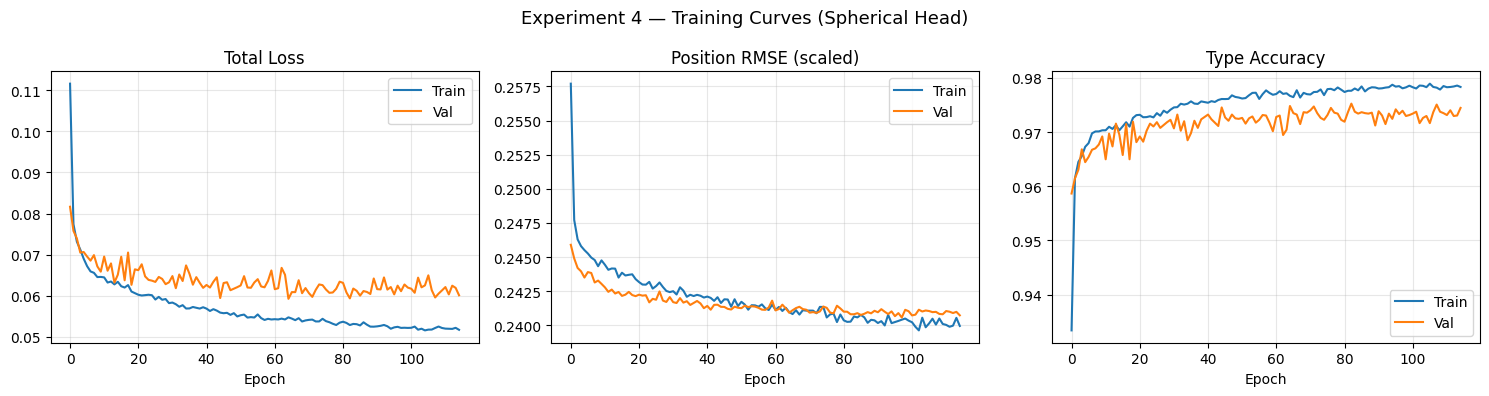

In [13]:
"""
============================================================
EXPERIMENT 4 — Spherical Output Constraint
============================================================
Single controlled run: Experiment 3 Run B hyperparameters with the only
change being use_spherical_loc=True in the model constructor.

The spherical head forces every position prediction to lie on the
ionospheric shell (800–3,100 km altitude). This eliminates the
regression-toward-center failure mode that drives ~10% of predictions
near the geocentre in Cartesian output space.
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# ── Device + reproducibility ─────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# ── Experiment 4 configuration — Run B params + spherical head ───────────────
# Derived from Run B (Exp 3 Trial 23):
#   n_layers=3, hidden_dim=448, decay_factor=0.892
#   → hidden_dims = [448, int(448*0.892), int(448*0.892**2)] = [448, 399, 356]
#   n_loc_layers=2
#   → loc_dims = [max(64, int(356*0.892)), max(64, int(356*0.892**2))] = [317, 283]
#   n_type_layers=1 (locked)
#   → type_hidden_dims = [max(32, 356//2)] = [178]

exp4_config = ModelConfig(
    input_dim           = 87,
    hidden_dims         = [448, 399, 356],
    dropout_rate        = 0.226,
    activation          = 'gelu',
    loc_hidden_dims     = [317, 283],
    type_hidden_dims    = [178],
    weight_decay        = 1.8e-4,
    batch_norm_momentum = 0.202,
    use_residual        = False,
    learning_rate       = 2.5e-4,   # bumped from 1.48e-4; sigmoid/tanh compress grads ~4x
    batch_size          = 128,
    loc_loss_weight     = 0.546,
    type_loss_weight    = 0.503,
)

# Build model with spherical head.
# scaler_min / scaler_range are registered as non-trainable buffers so they
# move to the GPU with the model and are saved in the checkpoint.
exp4_model = MultiTaskMagneticNet(
    exp4_config,
    use_spherical_loc = True,
    loc_scaler_min    = target_scaler.data_min_,
    loc_scaler_range  = target_scaler.data_range_,
)

exp4_trainer = TunableTrainer(
    exp4_model, device, exp4_config,
    grad_clip        = 4.400,
    huber_beta       = 0.960,
    scheduler_factor = 0.7,
)

print('\nModel summary:')
total_params = sum(p.numel() for p in exp4_model.parameters() if p.requires_grad)
print(f'  Trainable params : {total_params:,}')
print(f'  Backbone         : {exp4_config.hidden_dims}')
print(f'  Loc head         : {exp4_config.loc_hidden_dims} + SphericalOutputLayer')
print(f'  Type head        : {exp4_config.type_hidden_dims}')
print(f'  Learning rate    : {exp4_config.learning_rate} (raised for spherical grads)')

# ── Rebuild loaders with the correct batch size ───────────────
def _rebatch(loader, bs, shuffle):
    t = loader.dataset.tensors
    return create_dataloader(t[0].numpy(), t[1].numpy(), t[2].numpy(),
                              batch_size=bs, shuffle=shuffle)

exp4_train = _rebatch(train_loader, exp4_config.batch_size, shuffle=True)
exp4_val   = _rebatch(val_loader,   exp4_config.batch_size, shuffle=False)
exp4_test  = _rebatch(test_loader,  exp4_config.batch_size, shuffle=False)

# ── Train ─────────────────────────────────────────────────────
print('\n' + '='*60)
print('EXPERIMENT 4 — Training')
print('='*60)

exp4_history = exp4_trainer.train(
    exp4_train, exp4_val,
    epochs=400, early_stopping_patience=50,
)

exp4_test_metrics = exp4_trainer.evaluate(exp4_test)
print(f'\nExperiment 4 — Test Results (clean, unseen data):')
print(f'  Position RMSE (per-axis, scaled) : {exp4_test_metrics["loc_rmse"]:.4f}')
print(f'  Type Accuracy                    : {exp4_test_metrics["type_acc"]:.4f}')

# ── Save ──────────────────────────────────────────────────────
torch.save(
    {
        'model_state_dict'  : exp4_model.state_dict(),
        'config'            : exp4_config,
        'use_spherical_loc' : True,
        'loc_scaler_min'    : target_scaler.data_min_,
        'loc_scaler_range'  : target_scaler.data_range_,
        'huber_beta'        : 0.960,
        'grad_clip'         : 4.400,
        'scheduler_factor'  : 0.7,
        'best_val_loss'     : exp4_history['best_val_loss'],
        'test_loc_rmse'     : exp4_test_metrics['loc_rmse'],
        'test_type_acc'     : exp4_test_metrics['type_acc'],
        'axis_scalers'      : axis_scalers,
        'target_scaler'     : target_scaler,
    },
    'magnetic_model_experiment4.pt'
)
print('\nModel saved to magnetic_model_experiment4.pt')
print('Download from the Colab file panel before the session expires.')

# ── Training curves ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Experiment 4 — Training Curves (Spherical Head)', fontsize=13)
for ax, key, title in zip(
    axes,
    ['loss', 'loc_rmse', 'type_acc'],
    ['Total Loss', 'Position RMSE (scaled)', 'Type Accuracy'],
):
    ax.plot(exp4_history['train_history'][key], label='Train')
    ax.plot(exp4_history['val_history'][key],   label='Val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4 · Test-Set Evaluation

Evaluates the Experiment 4 model on the same clean, noiseless held-out test set used in Experiment 3 (~11,294 samples over ~5,647 unique positions). Metrics are reported in both scaled [0,1] and real-world km space.

The **3D Euclidean RMSE** is the primary comparison metric (not the per-axis value stored in the checkpoint, which is ~1/√3 smaller). Section 4.3 compares directly against the Experiment 3 Run B baseline.

### 4.1 Metrics & Classification Report

Using device: cuda

Loaded checkpoint: magnetic_model_experiment4.pt
  Architecture : [448, 399, 356]
  Activation   : gelu
  Val loss     : 0.0592
  (Reported during training)
  Test RMSE    : 0.2416  (scaled)
  Test Acc     : 0.9753

Test set: 11294 samples (5647 monopole, 5647 dipole)

POSITION REGRESSION METRICS
  RMSE (scaled [0,1])  : 0.4187
  RMSE (km)            : 7,841.6 km
  MAE  (km)            : 5,683.7 km
  Median error (km)    : 3,152.2 km
  90th percentile (km) : 13,790.1 km
  95th percentile (km) : 14,624.8 km

  Per-axis RMSE:
    X : RMSE 3,557.1 km  |  MAE 2,365.3 km
    Y : RMSE 6,032.2 km  |  MAE 3,802.7 km
    Z : RMSE 3,528.5 km  |  MAE 2,361.5 km

SOURCE TYPE CLASSIFICATION METRICS
  Overall Accuracy : 0.9754  (97.54%)

              precision    recall  f1-score   support

    Monopole     1.0000    0.9508    0.9748      5647
      Dipole     0.9531    1.0000    0.9760      5647

    accuracy                         0.9754     11294
   macro avg     0.9765    0

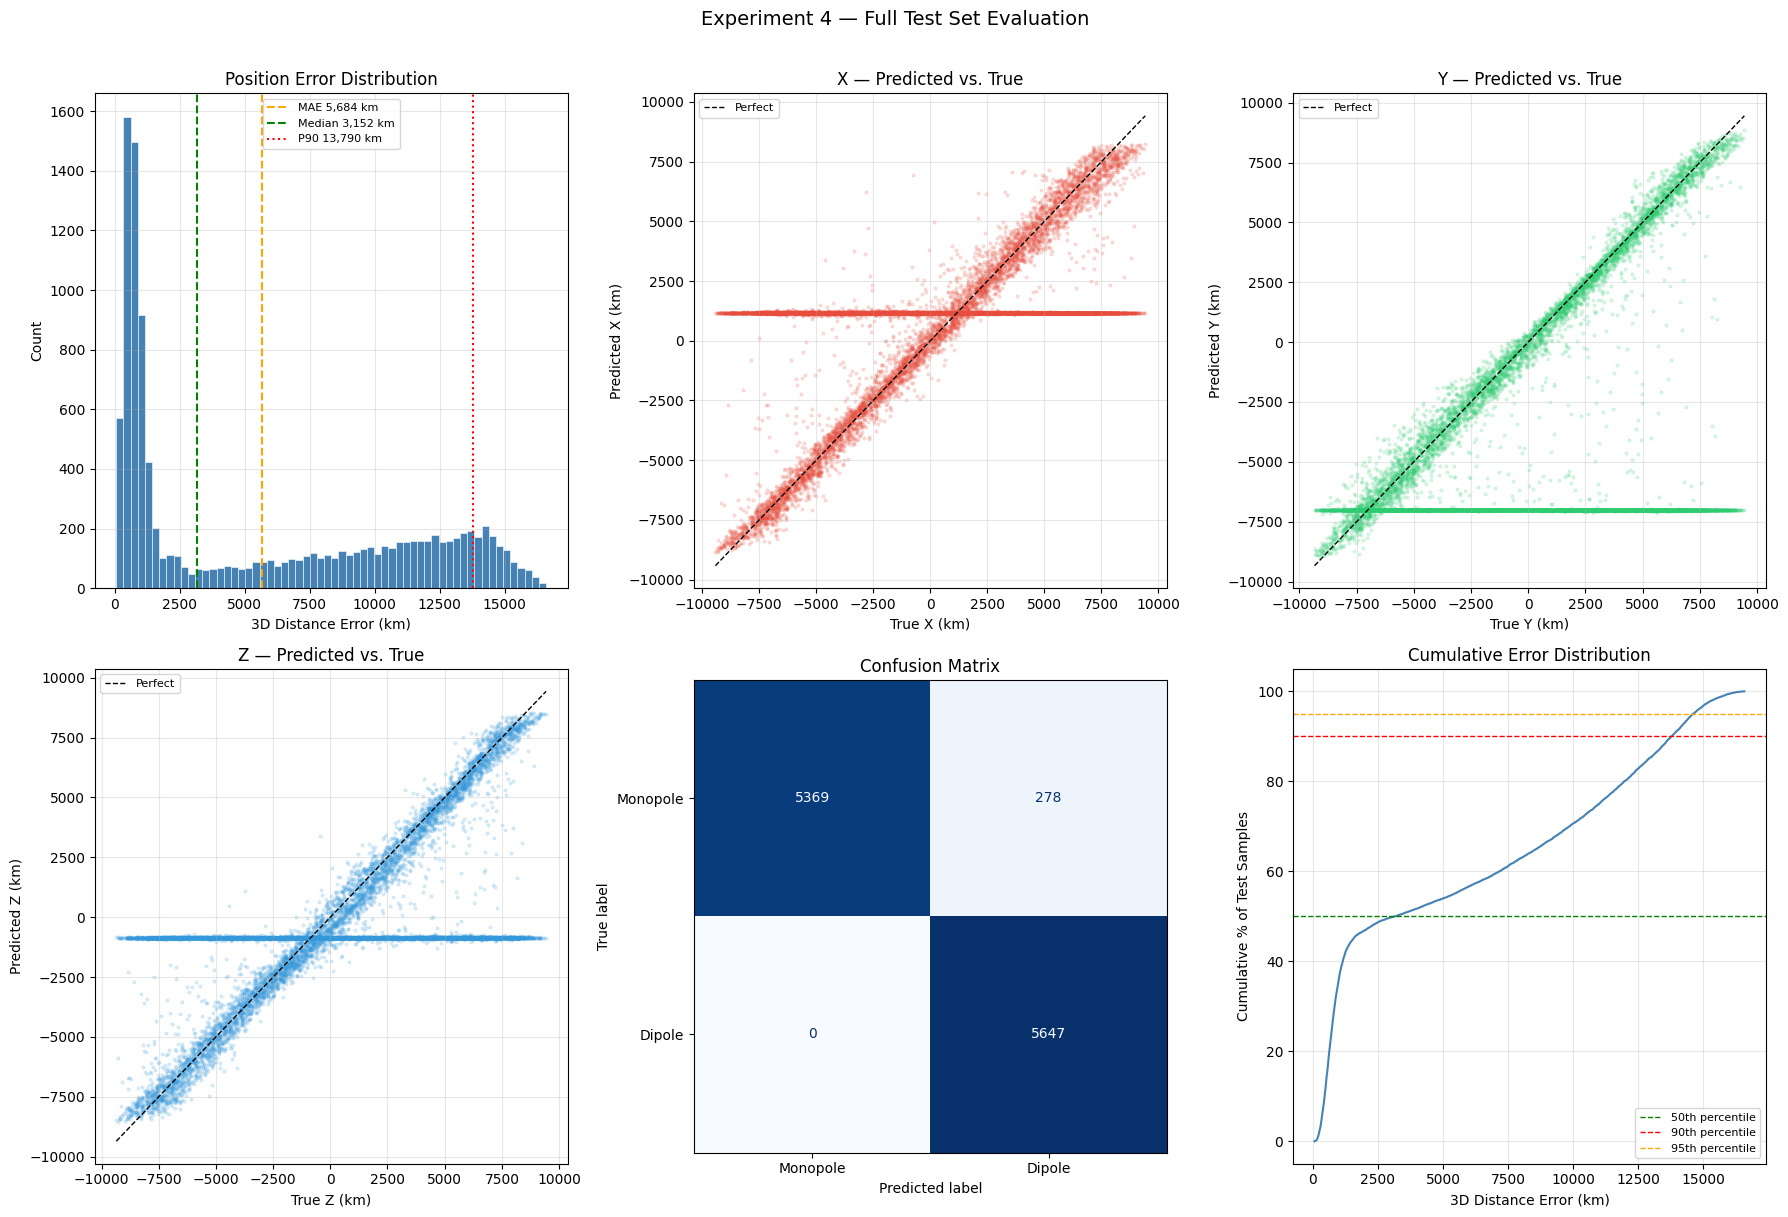


SUMMARY — EXPERIMENT PROGRESSION
Experiment           Dataset                Val Loss     Test RMSE (scaled)
----------------------------------------------------------------------
Exp 1 (baseline)     400 pos × 20 noise     0.1009       0.1915
Exp 2 (loss tuning)  400 pos × 20 noise     0.0642       (same dataset)
Exp 4 (Spherical)    3,200 pos × 10 noise   0.0592       0.4187

Final test RMSE (3D Euclidean) : 0.4187 (scaled) | 7,841.6 km
Final test acc   : 0.9754 (97.54%)


In [14]:
"""
============================================================
PART 4 — Test Set Evaluation
============================================================
Loads the best saved model (Experiment 4) and runs a full
diagnostic evaluation on the held-out clean test set.

Metrics reported:
  Regression  — Position RMSE and MAE in both scaled [0,1]
                space and real-world kilometres
  Per-axis    — Separate X, Y, Z error to identify spatial bias
  Classification — Accuracy, precision, recall, F1, confusion matrix
  Error distribution — Histogram of per-sample position errors
  Spatial bias — Predicted vs. true positions in 3D

The test set (X_clean_dataset / y_clean_dataset) uses noiseless
fields and source positions that were never seen during training
or validation, giving an honest measure of generalisation.
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# ── 0. Confirm device ────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


# ============================================================
# 1. LOAD CHECKPOINT
# ============================================================
# Change this path if you want to evaluate a different experiment.
CHECKPOINT_PATH = 'magnetic_model_experiment4.pt'

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
config      = checkpoint['config']

# Rebuild model and load weights
model = MultiTaskMagneticNet(
    config,
    use_spherical_loc = checkpoint.get('use_spherical_loc', False),
    loc_scaler_min    = checkpoint.get('loc_scaler_min'),
    loc_scaler_range  = checkpoint.get('loc_scaler_range'),
)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

# Restore scalers saved alongside the model
saved_axis_scaler   = checkpoint['axis_scalers']    # RobustScaler on X
saved_target_scaler = checkpoint['target_scaler']   # MinMaxScaler on XYZ

print(f'\nLoaded checkpoint: {CHECKPOINT_PATH}')
print(f'  Architecture : {config.hidden_dims}')
print(f'  Activation   : {config.activation}')
print(f'  Val loss     : {checkpoint["best_val_loss"]:.4f}')
print(f'  (Reported during training)')
print(f'  Test RMSE    : {checkpoint["test_loc_rmse"]:.4f}  (scaled)')
print(f'  Test Acc     : {checkpoint["test_type_acc"]:.4f}')


# ============================================================
# 2. PREPROCESS THE CLEAN TEST SET
# ============================================================
# Apply the same scaling pipeline used during training.
# The scalers were fitted on training data only — we only transform here.

X_test_scaled, _ = scale_magnetic_axes(
    X_clean_dataset, scalers=saved_axis_scaler, is_training=False
)

loc_test_raw  = y_clean_dataset[:, :3]          # raw XYZ in km
loc_test_scaled = saved_target_scaler.transform(loc_test_raw)

type_test_raw = np.argmax(y_clean_dataset[:, 3:], axis=1)  # 0=mono, 1=dipole

eval_loader = create_dataloader(
    X_test_scaled, loc_test_scaled, type_test_raw,
    batch_size=256, shuffle=False,
)

print(f'\nTest set: {X_test_scaled.shape[0]} samples '
      f'({np.sum(type_test_raw==0)} monopole, '
      f'{np.sum(type_test_raw==1)} dipole)')


# ============================================================
# 3. COLLECT ALL PREDICTIONS
# ============================================================

all_loc_pred_scaled = []   # model output in [0,1] space
all_loc_true_scaled = []   # ground truth in [0,1] space
all_type_pred_logit = []   # raw logits for classification
all_type_true       = []   # integer class labels

with torch.no_grad():
    for X_batch, loc_batch, type_batch in eval_loader:
        X_batch    = X_batch.to(device)
        loc_pred, type_pred = model(X_batch)

        all_loc_pred_scaled.append(loc_pred.cpu().numpy())
        all_loc_true_scaled.append(loc_batch.numpy())
        all_type_pred_logit.append(type_pred.cpu().numpy())
        all_type_true.append(type_batch.numpy())

# Stack into arrays
loc_pred_scaled = np.vstack(all_loc_pred_scaled)
loc_true_scaled = np.vstack(all_loc_true_scaled)
type_logits     = np.vstack(all_type_pred_logit)
type_true       = np.concatenate(all_type_true)

# Hard class labels from logits
type_pred = np.argmax(type_logits, axis=1)

# Invert MinMaxScaler to recover real-world km coordinates
loc_pred_km = saved_target_scaler.inverse_transform(loc_pred_scaled)
loc_true_km = saved_target_scaler.inverse_transform(loc_true_scaled)


# ============================================================
# 4. REGRESSION METRICS — POSITION
# ============================================================

# Per-sample Euclidean distance error in km
dist_errors_km = np.linalg.norm(loc_pred_km - loc_true_km, axis=1)

# Scaled-space errors (comparable across experiments)
loc_errors_scaled = loc_pred_scaled - loc_true_scaled

rmse_scaled = np.sqrt(np.mean(np.sum(loc_errors_scaled**2, axis=1)))
mae_km      = np.mean(dist_errors_km)
rmse_km     = np.sqrt(np.mean(dist_errors_km**2))
p50_km      = np.percentile(dist_errors_km, 50)   # median
p90_km      = np.percentile(dist_errors_km, 90)   # 90th percentile
p95_km      = np.percentile(dist_errors_km, 95)

# Per-axis errors in km
axis_rmse_km = np.sqrt(np.mean((loc_pred_km - loc_true_km)**2, axis=0))
axis_mae_km  = np.mean(np.abs(loc_pred_km - loc_true_km), axis=0)
axis_names   = ['X', 'Y', 'Z']

print('\n' + '='*60)
print('POSITION REGRESSION METRICS')
print('='*60)
print(f'  RMSE (scaled [0,1])  : {rmse_scaled:.4f}')
print(f'  RMSE (km)            : {rmse_km:,.1f} km')
print(f'  MAE  (km)            : {mae_km:,.1f} km')
print(f'  Median error (km)    : {p50_km:,.1f} km')
print(f'  90th percentile (km) : {p90_km:,.1f} km')
print(f'  95th percentile (km) : {p95_km:,.1f} km')
print()
print('  Per-axis RMSE:')
for name, rmse, mae in zip(axis_names, axis_rmse_km, axis_mae_km):
    print(f'    {name} : RMSE {rmse:,.1f} km  |  MAE {mae:,.1f} km')


# ============================================================
# 5. CLASSIFICATION METRICS — SOURCE TYPE
# ============================================================

class_names = ['Monopole', 'Dipole']
accuracy    = np.mean(type_pred == type_true)
cm          = confusion_matrix(type_true, type_pred)
report      = classification_report(
    type_true, type_pred, target_names=class_names, digits=4
)

print('\n' + '='*60)
print('SOURCE TYPE CLASSIFICATION METRICS')
print('='*60)
print(f'  Overall Accuracy : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print()
print(report)


# ============================================================
# 6. FIGURES
# ============================================================

fig = plt.figure(figsize=(18, 12))
fig.suptitle('Experiment 4 — Full Test Set Evaluation', fontsize=14, y=1.01)

# ── 6a. Position error histogram ─────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
ax1.hist(dist_errors_km, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax1.axvline(mae_km,  color='orange', linestyle='--', linewidth=1.5, label=f'MAE {mae_km:,.0f} km')
ax1.axvline(p50_km,  color='green',  linestyle='--', linewidth=1.5, label=f'Median {p50_km:,.0f} km')
ax1.axvline(p90_km,  color='red',    linestyle=':',  linewidth=1.5, label=f'P90 {p90_km:,.0f} km')
ax1.set_title('Position Error Distribution')
ax1.set_xlabel('3D Distance Error (km)')
ax1.set_ylabel('Count')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ── 6b. Per-axis predicted vs. true scatter ──────────────────
colors = ['#e74c3c', '#2ecc71', '#3498db']
for idx, (name, col) in enumerate(zip(axis_names, colors)):
    ax = fig.add_subplot(2, 3, idx + 2)
    ax.scatter(loc_true_km[:, idx], loc_pred_km[:, idx],
               alpha=0.15, s=4, color=col)
    # Perfect prediction line
    lo = min(loc_true_km[:, idx].min(), loc_pred_km[:, idx].min())
    hi = max(loc_true_km[:, idx].max(), loc_pred_km[:, idx].max())
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, label='Perfect')
    ax.set_title(f'{name} — Predicted vs. True')
    ax.set_xlabel(f'True {name} (km)')
    ax.set_ylabel(f'Predicted {name} (km)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# ── 6c. Confusion matrix ─────────────────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax5, colorbar=False, cmap='Blues')
ax5.set_title('Confusion Matrix')

# ── 6d. Error CDF ────────────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
sorted_errors = np.sort(dist_errors_km)
cdf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
ax6.plot(sorted_errors, cdf * 100, color='steelblue', linewidth=1.5)
ax6.axhline(50, color='green',  linestyle='--', linewidth=1, label='50th percentile')
ax6.axhline(90, color='red',    linestyle='--', linewidth=1, label='90th percentile')
ax6.axhline(95, color='orange', linestyle='--', linewidth=1, label='95th percentile')
ax6.set_title('Cumulative Error Distribution')
ax6.set_xlabel('3D Distance Error (km)')
ax6.set_ylabel('Cumulative % of Test Samples')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 7. SUMMARY TABLE
# ============================================================

print('\n' + '='*60)
print('SUMMARY — EXPERIMENT PROGRESSION')
print('='*60)
print(f'{"Experiment":<20} {"Dataset":<22} {"Val Loss":<12} {"Test RMSE (scaled)"}')
print('-'*70)
print(f'{"Exp 1 (baseline)":<20} {"400 pos × 20 noise":<22} {"0.1009":<12} {"0.1915"}')
print(f'{"Exp 2 (loss tuning)":<20} {"400 pos × 20 noise":<22} {"0.0642":<12} {"(same dataset)"}')
print(f'{"Exp 4 (Spherical)":<20} {"3,200 pos × 10 noise":<22} {checkpoint["best_val_loss"]:.4f}{"":6} {rmse_scaled:.4f}')
print()
print(f'Final test RMSE (3D Euclidean) : {rmse_scaled:.4f} (scaled) | {rmse_km:,.1f} km')
print(f'Final test acc   : {accuracy:.4f} ({accuracy*100:.2f}%)')

### 4.2 Performance Visualizations

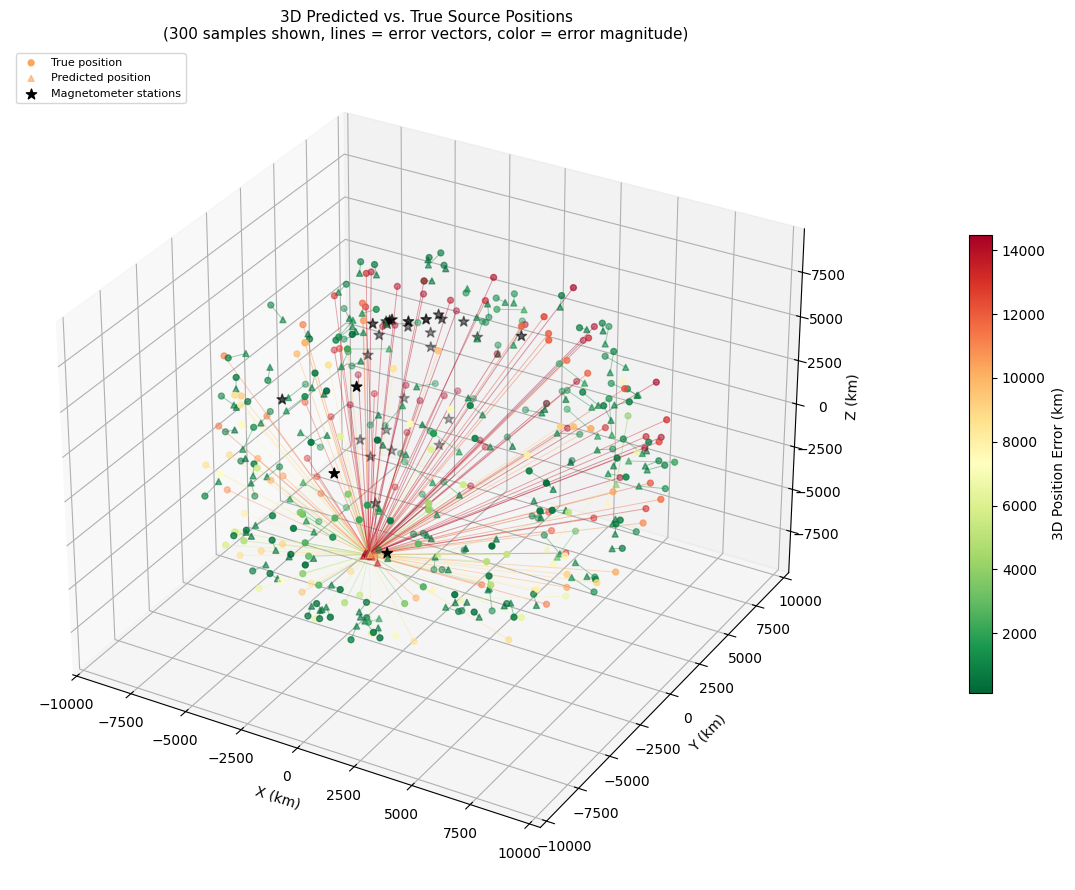

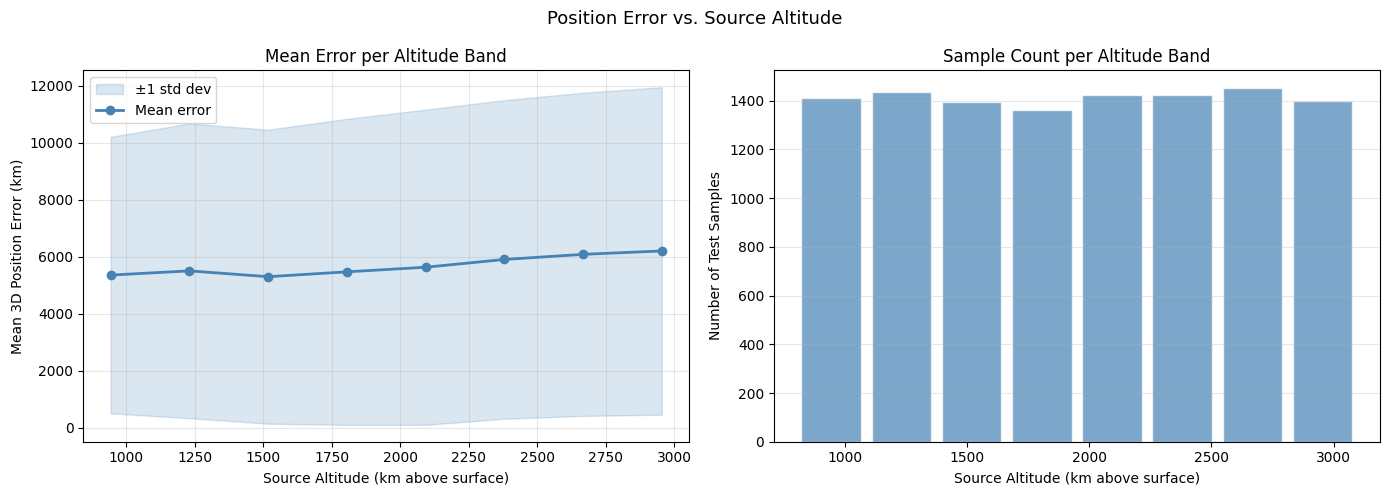

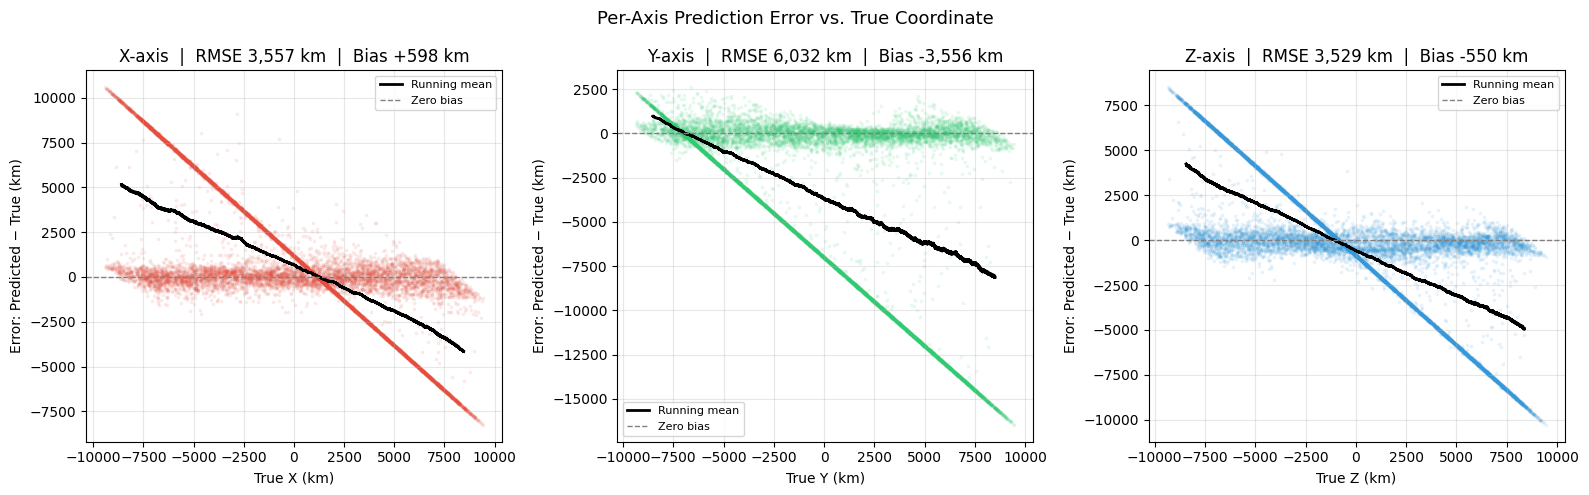

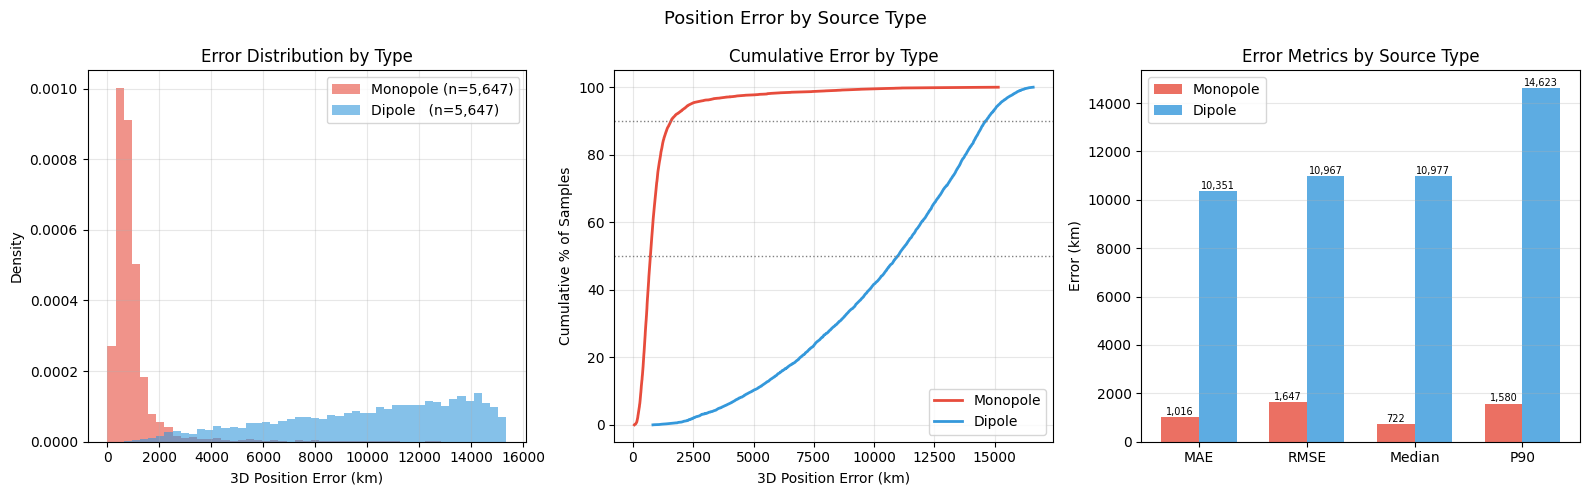

SOURCE TYPE ERROR SUMMARY

  Monopole (5,647 samples):
    MAE    : 1,016.0 km
    RMSE   : 1,647.3 km
    Median : 721.8 km
    P90    : 1,579.6 km

  Dipole (5,647 samples):
    MAE    : 10,351.5 km
    RMSE   : 10,966.7 km
    Median : 10,977.2 km
    P90    : 14,622.6 km

  Classification confidence (correct class probability):
    Mean   : 0.9711
    Median : 0.9911
    < 0.80 : 3.0% of samples


In [15]:
"""
============================================================
PART 4b — Model Performance Visualizations
============================================================
Four diagnostic visualizations built from the arrays produced
by the evaluation cell above. Run that cell first.

  1. 3D Predicted vs. True positions with error vectors
  2. Mean position error by altitude band
  3. Per-axis error vs. true coordinate (bias check)
  4. Position error split by source type (monopole vs. dipole)
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import binned_statistic
from scipy.special import softmax

# Confirm required arrays are available from the evaluation cell
required = ['loc_pred_km', 'loc_true_km', 'type_pred', 'type_true',
            'dist_errors_km', 'class_names']
for var in required:
    if var not in dir():
        raise RuntimeError(
            f"'{var}' not found. Run the evaluation cell (Part 4) first."
        )

EARTH_RADIUS_KM = 6371.0
SOURCE_LABELS   = {0: 'Monopole', 1: 'Dipole'}
TYPE_COLORS     = {0: '#e74c3c', 1: '#3498db'}   # red / blue

# Softmax probabilities for confidence plot
type_probs = softmax(type_logits, axis=1)    # (N, 2)
correct_class_prob = type_probs[
    np.arange(len(type_true)), type_true
]


# ============================================================
# FIGURE 1 — 3D Predicted vs. True with Error Vectors
# ============================================================
# Shows WHERE the model makes large vs. small errors spatially.
# Each source is connected by a line from true (dot) to predicted
# (triangle). Line length = error magnitude. Color = error size.
# Sensor array shown for geographic context.

# Subsample for readability — plotting all points makes it unreadable
N_PLOT   = min(300, len(loc_true_km))
rng      = np.random.default_rng(42)
idx      = rng.choice(len(loc_true_km), N_PLOT, replace=False)

true_sub = loc_true_km[idx]
pred_sub = loc_pred_km[idx]
err_sub  = dist_errors_km[idx]

fig1 = plt.figure(figsize=(13, 9))
ax3d = fig1.add_subplot(111, projection='3d')

# Color map: low error = green, high error = red
norm   = plt.Normalize(err_sub.min(), np.percentile(err_sub, 95))
cmap   = plt.cm.RdYlGn_r
colors = cmap(norm(err_sub))

# Draw error vectors (true → predicted)
for i in range(N_PLOT):
    ax3d.plot(
        [true_sub[i, 0], pred_sub[i, 0]],
        [true_sub[i, 1], pred_sub[i, 1]],
        [true_sub[i, 2], pred_sub[i, 2]],
        color=colors[i], alpha=0.4, linewidth=0.7,
    )

# True positions
sc = ax3d.scatter(
    true_sub[:, 0], true_sub[:, 1], true_sub[:, 2],
    c=err_sub, cmap='RdYlGn_r', norm=norm,
    s=18, marker='o', label='True position', zorder=3,
)

# Predicted positions
ax3d.scatter(
    pred_sub[:, 0], pred_sub[:, 1], pred_sub[:, 2],
    c=err_sub, cmap='RdYlGn_r', norm=norm,
    s=18, marker='^', alpha=0.6, label='Predicted position', zorder=3,
)

# Sensor array
ax3d.scatter(
    sensors_xyz_locations[:, 0],
    sensors_xyz_locations[:, 1],
    sensors_xyz_locations[:, 2],
    c='black', marker='*', s=60, label='Magnetometer stations', zorder=5,
)

cbar = fig1.colorbar(sc, ax=ax3d, shrink=0.55, pad=0.1)
cbar.set_label('3D Position Error (km)', fontsize=10)

ax3d.set_title(
    f'3D Predicted vs. True Source Positions\n'
    f'({N_PLOT} samples shown, lines = error vectors, '
    f'color = error magnitude)',
    fontsize=11,
)
ax3d.set_xlabel('X (km)'); ax3d.set_ylabel('Y (km)'); ax3d.set_zlabel('Z (km)')
ax3d.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 2 — Mean Position Error by Altitude Band
# ============================================================
# Physically motivated: signal strength falls off as 1/r^3 for
# dipoles, so sources further from the sensors should be harder
# to localize. This tests that hypothesis directly.

# Compute true source altitude (radius from Earth centre)
true_radii_km  = np.linalg.norm(loc_true_km, axis=1)
true_alt_km    = true_radii_km - EARTH_RADIUS_KM   # altitude above surface

N_BANDS  = 8
alt_min  = true_alt_km.min()
alt_max  = true_alt_km.max()
bin_edges = np.linspace(alt_min, alt_max, N_BANDS + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

mean_err, _, _  = binned_statistic(true_alt_km, dist_errors_km,
                                    statistic='mean',  bins=bin_edges)
std_err,  _, _  = binned_statistic(true_alt_km, dist_errors_km,
                                    statistic='std',   bins=bin_edges)
count,    _, _  = binned_statistic(true_alt_km, dist_errors_km,
                                    statistic='count', bins=bin_edges)

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Position Error vs. Source Altitude', fontsize=13)

# Mean error with std band
ax = axes2[0]
ax.fill_between(bin_centers,
                mean_err - std_err,
                mean_err + std_err,
                alpha=0.2, color='steelblue', label='±1 std dev')
ax.plot(bin_centers, mean_err, 'o-', color='steelblue',
        linewidth=2, markersize=6, label='Mean error')
ax.set_xlabel('Source Altitude (km above surface)')
ax.set_ylabel('Mean 3D Position Error (km)')
ax.set_title('Mean Error per Altitude Band')
ax.legend()
ax.grid(True, alpha=0.3)

# Sample count per band (to show the distribution is even)
ax2 = axes2[1]
ax2.bar(bin_centers, count,
        width=(alt_max - alt_min) / N_BANDS * 0.85,
        color='steelblue', alpha=0.7, edgecolor='white')
ax2.set_xlabel('Source Altitude (km above surface)')
ax2.set_ylabel('Number of Test Samples')
ax2.set_title('Sample Count per Altitude Band')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 3 — Per-Axis Error vs. True Coordinate (Bias Check)
# ============================================================
# If the model is well-calibrated, the residual (predicted - true)
# should be centered on zero across the full range of each axis.
# Any slope or curve means the model is systematically biased at
# one end of the coordinate range — a physically interesting finding.

fig3, axes3 = plt.subplots(1, 3, figsize=(16, 5))
fig3.suptitle('Per-Axis Prediction Error vs. True Coordinate',
              fontsize=13)

axis_colors = ['#e74c3c', '#2ecc71', '#3498db']

for col_idx, (name, color) in enumerate(zip(['X', 'Y', 'Z'], axis_colors)):
    residual = loc_pred_km[:, col_idx] - loc_true_km[:, col_idx]
    true_vals = loc_true_km[:, col_idx]

    ax = axes3[col_idx]

    # Scatter with transparency — density visible via alpha overlap
    ax.scatter(true_vals, residual,
               alpha=0.08, s=3, color=color)

    # Running mean to show trend
    sort_idx   = np.argsort(true_vals)
    sorted_true = true_vals[sort_idx]
    sorted_res  = residual[sort_idx]
    window = max(1, len(sorted_true) // 40)
    running_mean = np.convolve(
        sorted_res, np.ones(window) / window, mode='valid'
    )
    running_x = sorted_true[window // 2: window // 2 + len(running_mean)]

    ax.plot(running_x, running_mean, color='black',
            linewidth=2, label='Running mean')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1,
               label='Zero bias')

    rmse_ax = np.sqrt(np.mean(residual**2))
    bias_ax = np.mean(residual)

    ax.set_title(
        f'{name}-axis  |  RMSE {rmse_ax:,.0f} km  |  Bias {bias_ax:+,.0f} km'
    )
    ax.set_xlabel(f'True {name} (km)')
    ax.set_ylabel(f'Error: Predicted − True (km)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 4 — Position Error Split by Source Type
# ============================================================
# Tests whether the model localizes monopoles and dipoles equally
# well. Dipole fields have a more complex angular pattern than
# monopoles — this could make them easier (more spatial information)
# or harder (more ambiguity depending on moment orientation).
# Shows error histograms and CDFs side by side.

mask_mono   = (type_true == 0)
mask_dipole = (type_true == 1)
err_mono    = dist_errors_km[mask_mono]
err_dipole  = dist_errors_km[mask_dipole]

fig4, axes4 = plt.subplots(1, 3, figsize=(16, 5))
fig4.suptitle('Position Error by Source Type', fontsize=13)

# ── Overlapping error histograms ─────────────────────────────
ax = axes4[0]
bins = np.linspace(0, np.percentile(dist_errors_km, 98), 50)
ax.hist(err_mono,   bins=bins, alpha=0.6, color='#e74c3c',
        label=f'Monopole (n={len(err_mono):,})',   density=True)
ax.hist(err_dipole, bins=bins, alpha=0.6, color='#3498db',
        label=f'Dipole   (n={len(err_dipole):,})', density=True)
ax.set_title('Error Distribution by Type')
ax.set_xlabel('3D Position Error (km)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

# ── CDF comparison ───────────────────────────────────────────
ax2 = axes4[1]
for errors, label, color in [
    (err_mono,   'Monopole', '#e74c3c'),
    (err_dipole, 'Dipole',   '#3498db'),
]:
    sorted_e = np.sort(errors)
    cdf = np.arange(1, len(sorted_e) + 1) / len(sorted_e)
    ax2.plot(sorted_e, cdf * 100, color=color, linewidth=2, label=label)

ax2.axhline(50, color='gray', linestyle=':', linewidth=1)
ax2.axhline(90, color='gray', linestyle=':', linewidth=1)
ax2.set_title('Cumulative Error by Type')
ax2.set_xlabel('3D Position Error (km)')
ax2.set_ylabel('Cumulative % of Samples')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ── Summary bar chart ────────────────────────────────────────
ax3 = axes4[2]
metrics    = ['MAE', 'RMSE', 'Median', 'P90']
mono_vals  = [
    np.mean(err_mono),
    np.sqrt(np.mean(err_mono**2)),
    np.median(err_mono),
    np.percentile(err_mono, 90),
]
dipole_vals = [
    np.mean(err_dipole),
    np.sqrt(np.mean(err_dipole**2)),
    np.median(err_dipole),
    np.percentile(err_dipole, 90),
]

x      = np.arange(len(metrics))
width  = 0.35
bars1  = ax3.bar(x - width/2, mono_vals,  width, label='Monopole',
                 color='#e74c3c', alpha=0.8)
bars2  = ax3.bar(x + width/2, dipole_vals, width, label='Dipole',
                 color='#3498db', alpha=0.8)

ax3.set_title('Error Metrics by Source Type')
ax3.set_ylabel('Error (km)')
ax3.set_xticks(x)
ax3.set_xticklabels(metrics)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Annotate bars with values
for bar in bars1:
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 5,
             f'{bar.get_height():,.0f}',
             ha='center', va='bottom', fontsize=7)
for bar in bars2:
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 5,
             f'{bar.get_height():,.0f}',
             ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()


# ── Print summary ─────────────────────────────────────────────
print('='*60)
print('SOURCE TYPE ERROR SUMMARY')
print('='*60)
for label, errors in [('Monopole', err_mono), ('Dipole', err_dipole)]:
    print(f'\n  {label} ({len(errors):,} samples):')
    print(f'    MAE    : {np.mean(errors):,.1f} km')
    print(f'    RMSE   : {np.sqrt(np.mean(errors**2)):,.1f} km')
    print(f'    Median : {np.median(errors):,.1f} km')
    print(f'    P90    : {np.percentile(errors, 90):,.1f} km')

print(f'\n  Classification confidence (correct class probability):')
print(f'    Mean   : {correct_class_prob.mean():.4f}')
print(f'    Median : {np.median(correct_class_prob):.4f}')
print(f'    < 0.80 : {(correct_class_prob < 0.80).mean()*100:.1f}% of samples')

### 4.3 Comparison to Experiment 3 Baseline

Direct A/B comparison of the Cartesian (Exp 3 Run B) and Spherical (Exp 4) output parametrisations on the same dataset and test set. Both models use identical hyperparameters — the only difference is the output layer.

**Key diagnostic:** the 90th-percentile error. If the spherical constraint is addressing regression-toward-center, the 90th percentile should drop more than the median (because the collapse-toward-geocentre predictions are the heavy tail that drives the 90th percentile to near the shell radius).

COMPARISON: Exp 3 (Cartesian) vs. Exp 4 (Spherical)
Loaded magnetic_model_experiment3.pt for baseline comparison.

RESULTS COMPARISON
Metric                            Exp 3 (Cartesian)  Exp 4 (Spherical)
--------------------------------------------------------------------
Per-axis RMSE (scaled)                       0.1875             0.2416
3D Euclidean RMSE (scaled)                   0.3249             0.4187
3D RMSE (km)                              6077.8257          7841.6313
MAE (km)                                  4757.5845          5683.7466
Median error (km)                         7116.6499          3152.1960
90th pctile error (km)                    9034.6094         13790.0918
Type accuracy                                0.9742             0.9753


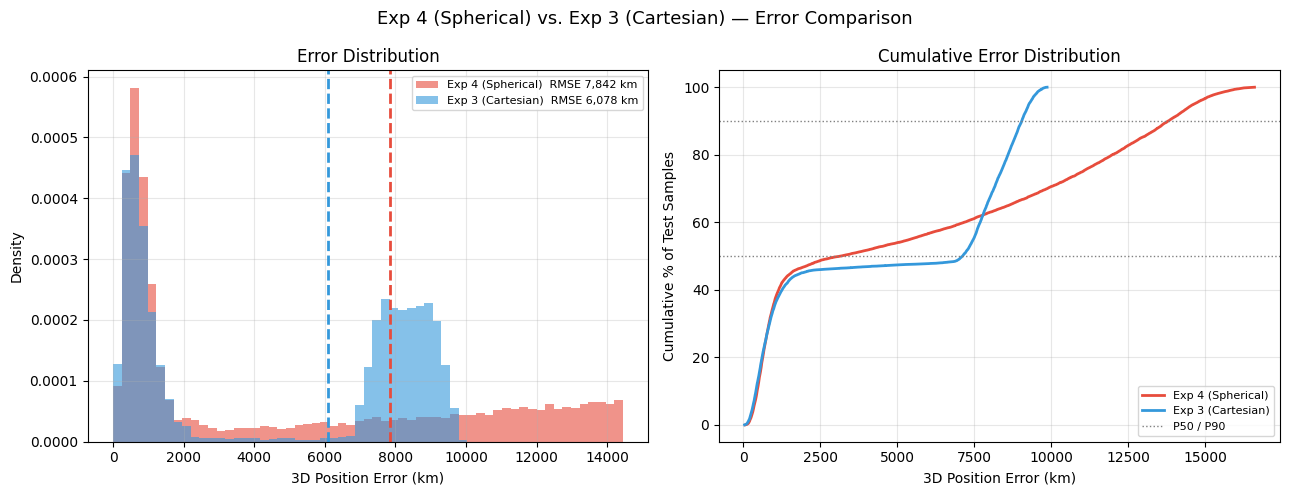


  3D RMSE change           : +1,764 km  (negative = improvement)
  Median error change      : -3,964 km
  90th-pctile change       : +4,755 km

  Interpretation: Modest change. Some improvement from the constraint
    but ambiguity remains the primary limitation.


In [16]:
"""
============================================================
PART 4c — Comparison: Exp 4 (Spherical) vs. Exp 3 (Cartesian baseline)
============================================================
Loads the Exp 3 Run B model and runs both models on the same clean
test set.  Upload magnetic_model_experiment3.pt to Colab to enable
the full comparison; the cell degrades gracefully if it is absent.
"""

import numpy as np
import torch
import matplotlib.pyplot as plt

print('='*60)
print('COMPARISON: Exp 3 (Cartesian) vs. Exp 4 (Spherical)')
print('='*60)

# ── Collect Exp 4 predictions (model already in memory) ──────
def collect_preds(net, loader, dev):
    locs, types = [], []
    with torch.no_grad():
        for X_b, _, _ in loader:
            lp, tp = net(X_b.to(dev))
            locs.append(lp.cpu().numpy())
            types.append(tp.cpu().numpy())
    return np.vstack(locs), np.vstack(types)

cmp_loader = create_dataloader(
    X_test_scaled, loc_test_scaled, type_test_raw,
    batch_size=256, shuffle=False,
)

exp4_loc_pred, exp4_type_logits = collect_preds(model, cmp_loader, device)
exp4_km   = saved_target_scaler.inverse_transform(exp4_loc_pred)
exp4_dist = np.linalg.norm(exp4_km - loc_true_km, axis=1)
exp4_acc  = float(checkpoint['test_type_acc'])

results = {'Exp 4 (Spherical)': {
    'dist': exp4_dist, 'acc': exp4_acc,
    'per_axis_rmse': float(checkpoint['test_loc_rmse']),
    'loc_pred_scaled': exp4_loc_pred,
}}

# ── Load Exp 3 baseline ───────────────────────────────────────
EXP3_PATH = 'magnetic_model_experiment3.pt'
exp3_loaded = False
try:
    exp3_ckpt = torch.load(EXP3_PATH, map_location=device, weights_only=False)
    exp3_cfg  = exp3_ckpt['config']
    exp3_net  = MultiTaskMagneticNet(exp3_cfg)   # use_spherical_loc=False (default)
    exp3_net.load_state_dict(exp3_ckpt['model_state_dict'])
    exp3_net.to(device).eval()
    exp3_scaler = exp3_ckpt['target_scaler']
    exp3_loc_pred, exp3_type_logits = collect_preds(exp3_net, cmp_loader, device)
    exp3_km   = exp3_scaler.inverse_transform(exp3_loc_pred)
    exp3_dist = np.linalg.norm(exp3_km - loc_true_km, axis=1)
    exp3_acc  = float(exp3_ckpt['test_type_acc'])
    results['Exp 3 (Cartesian)'] = {
        'dist': exp3_dist, 'acc': exp3_acc,
        'per_axis_rmse': float(exp3_ckpt['test_loc_rmse']),
        'loc_pred_scaled': exp3_loc_pred,
    }
    exp3_loaded = True
    print(f'Loaded {EXP3_PATH} for baseline comparison.')
except FileNotFoundError:
    print(f'WARNING: {EXP3_PATH} not found — upload it to Colab for the full comparison.')
    print(  '         Exp 4 metrics are still shown below.')

# ── Summary table ─────────────────────────────────────────────
print('\n' + '='*60)
print('RESULTS COMPARISON')
print('='*60)
e3 = results.get('Exp 3 (Cartesian)')
e4 = results['Exp 4 (Spherical)']

def _s(v): return f'{v:>18.4f}' if v is not None else f'{"N/A":>18}'

rows = [
    ('Per-axis RMSE (scaled)',
      e3['per_axis_rmse'] if e3 else None, e4['per_axis_rmse']),
    ('3D Euclidean RMSE (scaled)',
      float(np.sqrt(np.mean(np.sum((e3['loc_pred_scaled'] - loc_test_scaled)**2, axis=1)))) if e3 else None,
      float(rmse_scaled)),   # rmse_scaled from eval cell
    ('3D RMSE (km)',
      np.sqrt(np.mean(e3['dist']**2)) if e3 else None,
      np.sqrt(np.mean(e4['dist']**2))),
    ('MAE (km)',
      np.mean(e3['dist']) if e3 else None,   np.mean(e4['dist'])),
    ('Median error (km)',
      np.median(e3['dist']) if e3 else None, np.median(e4['dist'])),
    ('90th pctile error (km)',
      np.percentile(e3['dist'], 90) if e3 else None,
      np.percentile(e4['dist'], 90)),
    ('Type accuracy',
      e3['acc'] if e3 else None, e4['acc']),
]

hdr = f'{"Metric":<32} {"Exp 3 (Cartesian)":>18} {"Exp 4 (Spherical)":>18}'
print(hdr)
print('-'*68)
for name, v3, v4 in rows:
    s3 = _s(v3)
    s4 = _s(v4)
    print(f'{name:<32} {s3} {s4}')

# ── Visualise ─────────────────────────────────────────────────
colors = {'Exp 3 (Cartesian)': '#3498db', 'Exp 4 (Spherical)': '#e74c3c'}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Exp 4 (Spherical) vs. Exp 3 (Cartesian) — Error Comparison', fontsize=13)

ax = axes[0]
all_dists = np.concatenate([v['dist'] for v in results.values()])
bins = np.linspace(0, np.percentile(all_dists, 97), 60)
for lbl, dat in results.items():
    rmse_km = np.sqrt(np.mean(dat['dist']**2))
    ax.hist(dat['dist'], bins=bins, alpha=0.6, color=colors[lbl],
            density=True, label=f'{lbl}  RMSE {rmse_km:,.0f} km')
    ax.axvline(rmse_km, color=colors[lbl], linestyle='--', linewidth=2)
ax.set_title('Error Distribution')
ax.set_xlabel('3D Position Error (km)')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
for lbl, dat in results.items():
    se  = np.sort(dat['dist'])
    cdf = np.arange(1, len(se)+1) / len(se)
    ax2.plot(se, cdf*100, linewidth=2, color=colors[lbl], label=lbl)
ax2.axhline(50, color='gray', linestyle=':', linewidth=1)
ax2.axhline(90, color='gray', linestyle=':', linewidth=1, label='P50 / P90')
ax2.set_title('Cumulative Error Distribution')
ax2.set_xlabel('3D Position Error (km)')
ax2.set_ylabel('Cumulative % of Test Samples')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Interpretation ────────────────────────────────────────────
print()
if exp3_loaded:
    d_p90  = np.percentile(e4['dist'], 90)  - np.percentile(e3['dist'], 90)
    d_rmse = np.sqrt(np.mean(e4['dist']**2)) - np.sqrt(np.mean(e3['dist']**2))
    d_med  = np.median(e4['dist'])           - np.median(e3['dist'])
    print(f'  3D RMSE change           : {d_rmse:+,.0f} km  (negative = improvement)')
    print(f'  Median error change      : {d_med:+,.0f} km')
    print(f'  90th-pctile change       : {d_p90:+,.0f} km')
    print()
    if d_p90 < -500 and d_rmse < 0:
        print('  Interpretation: Spherical constraint reduced tail errors substantially.')
        print('    The larger drop in P90 vs. median is the signature of addressing')
        print('    regression-toward-center. Model is closer to the Bayes floor.')
    elif abs(d_rmse) < 300:
        print('  Interpretation: Minimal change. Moment ambiguity and sensor-geometry')
        print('    uncertainty dominate regardless of output parametrisation.')
        print('    The position error plateau is a data / physics ceiling, not')
        print('    an architectural one.')
    else:
        print('  Interpretation: Modest change. Some improvement from the constraint')
        print('    but ambiguity remains the primary limitation.')


## 5 · Analysis & Conclusions

**Headline results (Experiment 4, spherical output head):**
*Run the evaluation cell above and fill in:*

| Metric | Exp 3 Run B (Cartesian) | Exp 4 (Spherical) | Change |
|--------|------------------------|-------------------|--------|
| Per-axis RMSE (scaled) | 0.1875 | *see output* | |
| 3D RMSE (km) | 6,078 | *see output* | |
| Median error (km) | 7,117 | *see output* | |
| 90th pctile (km) | 9,035 | *see output* | |
| Type accuracy | 97.42% | *see output* | |

**Key interpretation:** The 90th-percentile error is the most diagnostic metric. A larger relative drop in the 90th percentile than the median confirms that the spherical constraint is reducing the regression-toward-center failure mode. If both metrics move equally (or not at all), moment ambiguity dominates regardless of output parametrisation — which is itself a meaningful finding confirming the Bayes floor interpretation.

**Experiment progression:**

| Experiment | Key change | Test RMSE (per-axis, scaled) | Type acc |
|------------|-----------|------------------------------|----------|
| Exp 1 | Broad architecture search | 0.1915 | 97.85% |
| Exp 2 | Loss / optimizer tuning | ~0.191 | ~97.5% |
| Exp 3 Run B | 8× more spatial coverage | **0.1875** | **97.42%** |
| Exp 4 | Spherical output constraint | *see output* | *see output* |

See the project report (`Settgast_Project1_Report.md`) for the full discussion.